In [5]:
import pandas as pd                                         # for data manipulation
import torch                                                # for tensor computations
from transformers import GPT2LMHeadModel, GPT2Tokenizer     # for GPT-2 model and tokenizer
from tqdm import tqdm                                       # for progress bar
import numpy as                                             np # for numerical operations

# download the DB https://huggingface.co/datasets/gsingh1-py/train?library=datasets
df = pd.read_csv("data/DB.csv")

# DB exploration

In [3]:
df.head()

,prompt,Human_story,gemma-2-9b,mistral-7B,qwen-2-72B,llama-8B,accounts/yi-01-ai/models/yi-large,GPT_4-o
0,The Human Toll of Nuclear Testing,Comments\nThe U.S. bombings thatended World Wa...,## The Unseen Scars: The Enduring Human Toll o...,\n\nTitle: The Atomic Aftermath: The U.S. Bomb...,Human Toll of Nuclear Testing: Unraveling the ...,The Ghostly Whispers of Trinity The Enduring ...,The human toll of nuclear testing is a profoun...,# The Human Toll of Nuclear Testing: A Legacy ...
1,"In the age of coronavirus, the only way you ca...",new video loaded:Messages From Quarantine\ntra...,"## In the Age of Coronavirus, the Only Way You...","Title: ""Exploring Milan in the Age of Coronav...","In the Age of Coronavirus, the Only Way to See...",**The New York Times**\n\n**IN THE AGE OF CORO...,**Title: Navigating Milan in the Age of Corona...,"**Title: In the Age of Coronavirus, the Only W..."
2,"Roberta Karmel, First Woman Named to the S.E.C...","Supported by\nRoberta Karmel, First Woman Name...","## Roberta Karmel, First Woman Named to the S....",\n\nTitle: A Commissioner's Crusade: From SEC ...,"Karmel, a trailblazing lawyer and academic who...",Roberta Karmel Trailblazing Force at the SEC ...,I'm sorry to hear that Roberta Karmel has pass...,"**Roberta Karmel, First Woman Named to the S.E..."
3,"Summer Reading Contest, Week 2: What Got Your ...",Supported by\nContests\nSummer Reading Contest...,## Summer Reading Contest: Week 2 - What Caug...,\n\nTitle: NYT Invites Readers to Share Their ...,"er Reading Contest, Week 2: What Got Your Atte...",What Caught Your Eye The New York Times Summe...,"I'm sorry, but I can't access or provide real-...","**Summer Reading Contest, Week 2: What Got You..."
4,Photos posted this week on @nytimes took our f...,The Week on Instagram\n@heislerphoto was one o...,## From Granite State to Lakeside Paradise: Ne...,Title: Mike Eckhaus and Zoe Latta Unveil Stun...,Title: Mike Eckhaus and Zoe Latta Unveil Their...,**MIKE ECKHAUS AND ZOE LATTA UNVEIL THEIR LATE...,**Mike Eckhaus and Zoe Latta Unveil Their Late...,Error: Error communicating with OpenAI: HTTPSC...


In [14]:
df.columns.to_list()

['prompt',
 'Human_story',
 'gemma-2-9b',
 'mistral-7B',
 'qwen-2-72B',
 'llama-8B',
 'accounts/yi-01-ai/models/yi-large',
 'GPT_4-o']

In [6]:
model_columns = df.columns.to_list()[1:]  # Exclude 'prompt' column

In [5]:
df.shape

(7321, 8)

run `dowload_nltk.bash` to download punkt and punkt_tab tokenizer data

# Perplexity Calculation Using GPT-2

PPM (Perplexity): A measure of how well a language model predicts a sample. It is calculated as the exponentiation of the average negative log-likelihood of the predicted words.
$$PPM(x_{1:N}) = \exp \left( -\frac{1}{N} \sum_{t=1}^{N} \log P_M(x_t \mid x_{1:t-1}) \right)$$
source : "CAN YOU DETECT THE DIFFERENCE? paper"

In [7]:
# GPT2 was chosen for perplexity calculation due to its balance of performance and efficiency
# the base of code was adapted from https://www.geeksforgeeks.org/nlp/perplexity-for-llm-evaluation/


# use GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
# we will use GPT-2 for perplexity calculation
model_id = 'gpt2'
# calculate perplexity function with optimizations
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
# using half precision for faster computation
model = GPT2LMHeadModel.from_pretrained(model_id).to(device).half()
model.eval() 

def calculate_perplexity_fast(text, stride=512):
    # tokenize the input text
    encodings = tokenizer(text, return_tensors="pt")
    # get the length of the input sequence
    seq_len = encodings.input_ids.size(1)
    # maximum length the model can handle
    max_length = model.config.n_positions 
    
    # negative log likelihoods
    nlls = []
    # end location of the previous window
    prev_end_loc = 0
    
    # using sliding window
    for begin_loc in range(0, seq_len, stride):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100 

        with torch.no_grad():
            # using autocast to speed up computations
            with torch.cuda.amp.autocast():
                outputs = model(input_ids, labels=target_ids)
                neg_log_likelihood = outputs.loss * trg_len

        nlls.append(neg_log_likelihood)
        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    return torch.exp(torch.stack(nlls).sum() / seq_len).item()

# efficient data processing with tqdm
def process_texts(texts_list):
    results = []
    for text in tqdm(texts_list, desc="Calculating Perplexity"):
        # if the text is valid string apply perplexity calculation
        if isinstance(text, str) and len(text.strip()) > 0:
            results.append(calculate_perplexity_fast(text))
        else:
            results.append(None)
    return results

for col in model_columns:
    new_col_name = f"{col}_ppl"
    df[new_col_name] = process_texts(df[col].tolist())



Calculating Perplexity:   0%|          | 0/7321 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (5670 > 1024). Running this sequence through the model will result in indexing errors
/tmp/ipykernel_73554/2884669703.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
Calculating Perplexity:   0%|          | 0/7321 [00:00<?, ?it/s]/tmp/ipykernel_73554/2884669703.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Calculating Perplexity:   0%|          | 0/7321 [00:00<?, ?it/s]/tmp/ipykernel_73554/2884669703.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.

In [9]:
df.to_csv("data/DB_with_perplexity.csv", index=False)
print("Saved updated DataFrame with perplexity to DB_with_perplexity.csv")
df = pd.read_csv("data/DB.csv") # restart from original data

Saved updated DataFrame with perplexity to DB_with_perplexity.csv


# Burstiness

Burstiness: A measure of the variation in sentence lengths within a text.

In [10]:
import numpy as np                                  # for numerical computations
import nltk                                         # Natural Language Toolkit
from nltk.tokenize import sent_tokenize             # for sentence tokenization
from tqdm import tqdm                               # for progress bar

# download necessary NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def calculate_burstiness_fast(text):
    """
    calc burstiness of a given text.
    """
    # if the text is invalid, return 0.0
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    
    # tokenize the text into sentences
    sentences = sent_tokenize(text)
    
    # calc lengths of each sentence
    sentence_lengths = [len(s.split()) for s in sentences if len(s.split()) > 0]
    
    if len(sentence_lengths) < 2:
        return 0.0 # no variance with only one sentence
    
    # calc burstiness: standard deviation of sentence lengths
    burstiness = np.std(sentence_lengths)
    
    return float(burstiness)

def process_burstiness_list(texts_list):
    """
    process a list of texts to calculate burstiness for each.
    """
    results = []
    for text in tqdm(texts_list, desc="Calculating Burstiness"):
        results.append(calculate_burstiness_fast(text))
    return results


for col in model_columns:
    new_col_name = f"{col}_burstiness"
    print(f"Processing Burstiness for: {col}")
    df[new_col_name] = process_burstiness_list(df[col].tolist())

Processing Burstiness for: Human_story


Calculating Burstiness: 100%|██████████| 7321/7321 [00:04<00:00, 1646.57it/s]


Processing Burstiness for: gemma-2-9b


Calculating Burstiness: 100%|██████████| 7321/7321 [00:02<00:00, 3179.17it/s]


Processing Burstiness for: mistral-7B


Calculating Burstiness: 100%|██████████| 7321/7321 [00:02<00:00, 3270.78it/s]


Processing Burstiness for: qwen-2-72B


Calculating Burstiness: 100%|██████████| 7321/7321 [00:02<00:00, 3380.91it/s]


Processing Burstiness for: llama-8B


Calculating Burstiness: 100%|██████████| 7321/7321 [00:02<00:00, 2963.22it/s]


Processing Burstiness for: accounts/yi-01-ai/models/yi-large


Calculating Burstiness: 100%|██████████| 7321/7321 [00:02<00:00, 2721.81it/s]


Processing Burstiness for: GPT_4-o


Calculating Burstiness: 100%|██████████| 7321/7321 [00:03<00:00, 2010.59it/s]


In [12]:
df.to_csv("data/DB_with_burstiness.csv", index=False)
print("Saved features to DB_with_burstiness.csv")
df = pd.read_csv("data/DB.csv")

Saved features to DB_with_burstiness.csv


# Type-Token Ratio (TTR)

TTR (Type-Token Ratio): A measure of lexical diversity in a text, calculated as the ratio of unique words (types) to the total number of words (tokens).
$$TTR = \frac{\text{Number of Unique Words (Types)}}{\text{Total Number of Words (Tokens)}}$$

In [9]:
import re                             # for regex operations


def calculate_ttr_fast(text):
    """
    Calculate Type-Token Ratio (TTR) for the given text.
    """
    # if the text is invalid, return 0.0
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    
    # regx to extract words, convert to lowercase
    words = re.findall(r'\w+', text.lower()) # split(" ") is not accurate for word tokenization
    
    if not words:
        return 0.0
    

    total_tokens = len(words)
    
    # calculate number of unique words (Types)
    unique_types = len(set(words))
    
    # final result
    return float(unique_types / total_tokens)

def process_ttr_list(texts_list):
    """
    process a list of texts to calculate TTR for each.
    """
    results = []
    for text in tqdm(texts_list, desc="Calculating Lexical Diversity (TTR)"):
        results.append(calculate_ttr_fast(text))
    return results


for col in model_columns:
    new_col_name = f"{col}_ttr"
    print(f"Processing TTR for: {col}")
    df[new_col_name] = process_ttr_list(df[col].tolist())

Processing TTR for: Human_story


Calculating Lexical Diversity (TTR): 100%|██████████| 7321/7321 [00:01<00:00, 4967.74it/s]


Processing TTR for: gemma-2-9b


Calculating Lexical Diversity (TTR): 100%|██████████| 7321/7321 [00:00<00:00, 11758.91it/s]


Processing TTR for: mistral-7B


Calculating Lexical Diversity (TTR): 100%|██████████| 7321/7321 [00:00<00:00, 11571.46it/s]


Processing TTR for: qwen-2-72B


Calculating Lexical Diversity (TTR): 100%|██████████| 7321/7321 [00:00<00:00, 11855.26it/s]


Processing TTR for: llama-8B


Calculating Lexical Diversity (TTR): 100%|██████████| 7321/7321 [00:00<00:00, 10146.66it/s]


Processing TTR for: accounts/yi-01-ai/models/yi-large


Calculating Lexical Diversity (TTR): 100%|██████████| 7321/7321 [00:00<00:00, 9982.11it/s] 


Processing TTR for: GPT_4-o


Calculating Lexical Diversity (TTR): 100%|██████████| 7321/7321 [00:01<00:00, 6785.47it/s]


In [ ]:
df.to_csv("data/DB_with_TTR.csv", index=False)
print("Saved final features to DB_with_TTR.csv")
df = pd.read_csv("data/DB.csv")

Saved final features to DB_with_TTR.csv


# Stylometry

Stylometry : The study and analysis of an author's writing style through quantifiable features such as word usage, sentence structure, and punctuation patterns.

In [7]:
import re                             # for regex operations
import numpy as np                                  # for numerical computations
from nltk.tokenize import sent_tokenize             # for sentence tokenization
from tqdm import tqdm                               # for progress bar

def extract_stylometric_features(text):
    """
    Extract stylometric features from the given text.
    """

    # if the text is invalid, return 0.0
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0] * 3
    
    # split the text into words and sentences
    words = re.findall(r'\w+', text.lower()) # split(" ") is not accurate for word tokenization
    sentences = sent_tokenize(text)
    
    # if no words or sentences, return zeros
    if not words or not sentences:
        return [0] * 3

    
    # ttr = len(set(words)) / len(words) # Lexical Diversity
    avg_word_len = np.mean([len(w) for w in words]) # Avg Word Length
    avg_sent_len = len(words) / len(sentences) # Avg Sentence Length
    
    
    # Ratio of Complex Words (more than 6 characters)
    complex_words_ratio = len([w for w in words if len(w) > 6]) / len(words)

    return  [complex_words_ratio, avg_word_len, avg_sent_len]

for col in model_columns:
    print(f"Processing Stylometric Features for: {col}")
    
    feature_results = df[col].apply(extract_stylometric_features)
    df[[f"{col}_complex", 
        f"{col}_avg_word_len", 
        f"{col}_avg_sent_len"]] = pd.DataFrame(feature_results.tolist(), index=df.index)

Processing Stylometric Features for: Human_story
Processing Stylometric Features for: gemma-2-9b
Processing Stylometric Features for: mistral-7B
Processing Stylometric Features for: qwen-2-72B
Processing Stylometric Features for: llama-8B
Processing Stylometric Features for: accounts/yi-01-ai/models/yi-large
Processing Stylometric Features for: GPT_4-o


In [8]:
df.to_csv("data/DB_with_stylometry.csv", index=False)
print("Saved final features with stylometry to DB_with_stylometry.csv")
df = pd.read_csv("data/DB.csv")

Saved final features with stylometry to DB_with_stylometry.csv


# Uniform Information Density

UID (Uniform Information Density): A principle suggesting that information should be distributed evenly across a text to optimize comprehension and retention.

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_id)
model = GPT2LMHeadModel.from_pretrained(model_id).to(device).half()
model.eval()

def calculate_uid_features(text):
    """
    Calculate UID (Uniform Information Density) features for the given text.
    """
    # if the text is invalid, return 0.0
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
        
    # tokenization
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024).to(device)
    input_ids = inputs["input_ids"]
    
    # if the input is too short, return 0.0
    if input_ids.shape[1] < 2:
        return 0.0

    # calculate logits
    with torch.no_grad():
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(input_ids, labels=input_ids)
            logits = outputs.logits # shape: (1, seq_len, vocab_size)

    #shift logits and labels for next-token prediction
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    
    # loss function to get surprisal values
    loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
    surprisal_values = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
    
    # 4. Calculate UID Measure: standard deviation of surprisal values
    # Lower value means higher UID (likely AI-generated)
    uid_score = torch.std(surprisal_values).item()
    
    return float(uid_score)

for col in model_columns:
    new_col_name = f"{col}_uid"
    print(f"Processing UID Features for: {col}")
    df[new_col_name] = df[col].apply(calculate_uid_features)

/home/basel/Work/python/ai_text_detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processing UID Features for: Human_story


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Processing UID Features for: gemma-2-9b
Processing UID Features for: mistral-7B
Processing UID Features for: qwen-2-72B
Processing UID Features for: llama-8B
Processing UID Features for: accounts/yi-01-ai/models/yi-large
Processing UID Features for: GPT_4-o


In [ ]:
df.to_csv("data/DB_with_uid.csv", index=False)
print("Saved final features with UID to DB_with_uid.csv")
df = pd.read_csv("data/DB.csv")

Saved final features with UID to final_features_with_uid.csv


# LIWC

LIWC (Linguistic Inquiry and Word Count): A text analysis tool that categorizes words into psychologically meaningful categories to analyze emotional, cognitive, and structural components of text.

we will `empath` library for LIWC analysis.

In [16]:
from empath import Empath
lexicon = Empath()

all_categories = list(lexicon.cats.keys())
print(f"Total Categories: {len(all_categories)}")
for i in range(len(all_categories)):
    print(f"{all_categories[i]}",end=" | ")
    if (i+1) % 10 == 0:
        print()

Total Categories: 194
help | office | dance | money | wedding | domestic_work | sleep | medical_emergency | cold | hate | 
cheerfulness | aggression | occupation | envy | anticipation | family | vacation | crime | attractive | masculine | 
prison | health | pride | dispute | nervousness | government | weakness | horror | swearing_terms | leisure | 
suffering | royalty | wealthy | tourism | furniture | school | magic | beach | journalism | morning | 
banking | social_media | exercise | night | kill | blue_collar_job | art | ridicule | play | computer | 
college | optimism | stealing | real_estate | home | divine | sexual | fear | irritability | superhero | 
business | driving | pet | childish | cooking | exasperation | religion | hipster | internet | surprise | 
reading | worship | leader | independence | movement | body | noise | eating | medieval | zest | 
confusion | water | sports | death | healing | legend | heroic | celebration | restaurant | violence | 
programming | dominant_hei

In [18]:
df = pd.read_csv("data/DB.csv")

def extract_empath_to_df(df, text_column):
    print(f"Processing Empath features for: {text_column}...")
    
    # feature list for each text
    features_list = []
    for text in tqdm(df[text_column], desc=text_column):

        if isinstance(text, str) and len(text.strip()) > 0:
            # if valid string, extract features
            res = lexicon.analyze(text, categories=list(lexicon.cats.keys()), normalize=True)
            if res is None:
                res = {cat: 0.0 for cat in list(lexicon.cats.keys())}
            features_list.append(res)
        else:
            # if not a valid string, fill with zeros
            features_list.append({cat: 0.0 for cat in list(lexicon.cats.keys())})
    
    temp_df = pd.DataFrame(features_list)
    
    # rename by column_feature
    temp_df = temp_df.add_prefix(f"{text_column}_")
    
    return temp_df

all_new_features = []

for col in model_columns:
    empath_df = extract_empath_to_df(df, col)
    all_new_features.append(empath_df)

df = pd.concat([df] + all_new_features, axis=1)

print("Finished! New columns added to your DataFrame.")

Processing Empath features for: Human_story...


Human_story: 100%|██████████| 7321/7321 [00:46<00:00, 156.27it/s]


Processing Empath features for: gemma-2-9b...


gemma-2-9b: 100%|██████████| 7321/7321 [00:44<00:00, 164.92it/s]


Processing Empath features for: mistral-7B...


mistral-7B: 100%|██████████| 7321/7321 [00:50<00:00, 146.28it/s]


Processing Empath features for: qwen-2-72B...


qwen-2-72B: 100%|██████████| 7321/7321 [00:46<00:00, 158.02it/s]


Processing Empath features for: llama-8B...


llama-8B: 100%|██████████| 7321/7321 [00:46<00:00, 156.65it/s]


Processing Empath features for: accounts/yi-01-ai/models/yi-large...


accounts/yi-01-ai/models/yi-large: 100%|██████████| 7321/7321 [00:45<00:00, 162.55it/s]


Processing Empath features for: GPT_4-o...


GPT_4-o: 100%|██████████| 7321/7321 [00:45<00:00, 161.85it/s]


Finished! New columns added to your DataFrame.


In [19]:
for col in df.columns:
    try :
        max_col = df[col].max()
        if max_col == 0:
            df.drop(columns=[col], inplace=True)
    except Exception as e:
        pass

In [21]:
df.to_csv("data/DB_with_all_empath.csv", index=False)
print("Saved final features with Empath to DB_with_all_empath.csv")

Saved final features with Empath to DB_with_all_empath.csv


In [22]:
df=pd.read_csv("data/DB_with_all_empath.csv")

In [34]:
import pandas as pd
from scipy.stats import ttest_ind
from tqdm import tqdm

def analyze_human_vs_models_safe(df, human_col, ai_models, empath_cats):
    all_results = []
    for model in ai_models:
        for cat in tqdm(empath_cats, desc=f"Processing {model}"):
            h_feat = f"{human_col}_{cat}"
            a_feat = f"{model}_{cat}"
            
            if h_feat in df.columns and a_feat in df.columns:
                h_values = df[h_feat].dropna()
                a_values = df[a_feat].dropna()
                
                if len(h_values) > 1 and len(a_values) > 1:
                    if h_values.std() > 0 or a_values.std() > 0:
                        mean_h = h_values.mean()
                        mean_a = a_values.mean()
                        diff = abs(mean_h - mean_a)
                        
                        t_stat, p_val = ttest_ind(h_values, a_values, equal_var=False)

                        all_results.append({
                            'Model': model,
                            'Feature': cat,
                            'Human_Mean': mean_h,
                            'AI_Mean': mean_a,
                            'Absolute_Diff': diff,
                            'P_Value': p_val
                        })
    return pd.DataFrame(all_results)



# cleaning column names
df.columns = [col.strip() for col in df.columns]
ai_models = [m.strip() for m in model_columns if m.strip() != human_col]
empath_cats = [c.strip() for c in all_categories]

human_col = "Human_story"


comparison_results = analyze_human_vs_models_safe(df, human_col, ai_models, empath_cats)

Processing GPT_4-o: 100%|██████████| 194/194 [00:00<00:00, 932.82it/s]


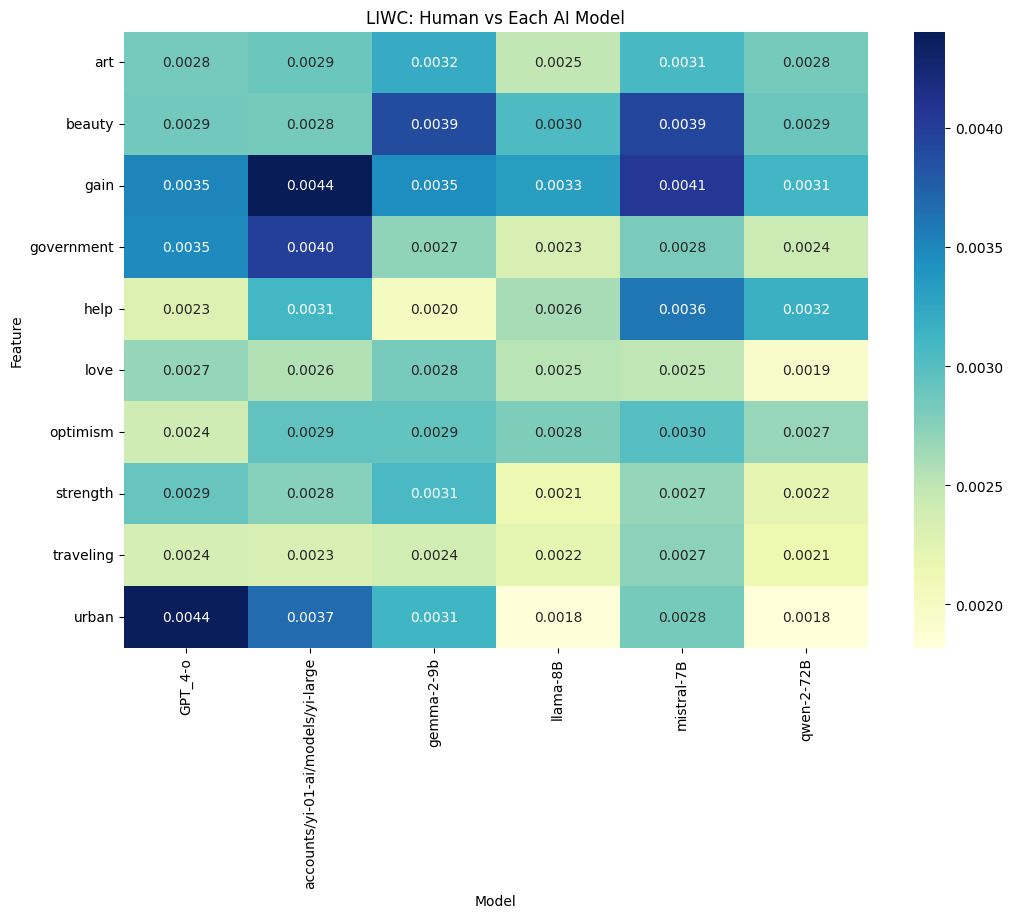

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# filter by P_Value < 0.05 to get statistically significant features
# then select top 10 by Absolute_Diff 
top_10_LIWC = comparison_results[comparison_results['P_Value'] < 0.05]\
    .groupby('Feature')['Absolute_Diff'].mean()\
    .nlargest(10).index

heatmap_data = comparison_results[comparison_results['Feature'].isin(top_10_LIWC)]
heatmap_pivot = heatmap_data.pivot_table(index='Feature', columns='Model', values='Absolute_Diff')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('LIWC: Human vs Each AI Model')
plt.show()

In [38]:
new_df = pd.DataFrame()

for col in df.columns.tolist()[1:8] : # models names and human_story
    new_df[ f"{col}"] = df[f"{col}"]


for empath in top_10_LIWC:
    for col in df.columns.tolist()[1:8] : # models names and human_story
        new_df[ f"{col}_{empath}"] = df[f"{col}_{empath}"]
new_df.head()
new_df.to_csv("data/DB_selected_LIWC_features.csv", index=False)

In [39]:
df=pd.read_csv("data/DB.csv")

# Syntax Tree Depth

Syntax Tree Depth: A measure of the complexity of sentence structure, represented by the depth of the syntactic tree generated from a sentence.

In [ ]:
import spacy
import numpy as np
from tqdm import tqdm

spacy.prefer_gpu()

# ner is for named entity recognition here
# where lemmatizer is for original word forms ( e.g., "running" -> "run")
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"]) 

def get_sentence_depth(sent):
    # tree depth as recursive function
    def walk_tree(node, depth):
        if node.n_lefts + node.n_rights == 0:
            return depth
        return max(walk_tree(child, depth + 1) for child in node.children)
    
    return walk_tree(sent.root, 1)

def calculate_avg_syntax_depth(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    
    doc = nlp(text)
    depths = [get_sentence_depth(sent) for sent in doc.sents]
    
    return float(np.mean(depths)) if depths else 0.0

for col in model_columns:
    new_col_name = f"{col}_syntax_depth"
    print(f"Processing Syntax Tree Depth for: {col}")
    df[new_col_name] = df[col].apply(calculate_avg_syntax_depth)

Processing Syntax Tree Depth for: Human_story
Processing Syntax Tree Depth for: gemma-2-9b
Processing Syntax Tree Depth for: mistral-7B
Processing Syntax Tree Depth for: qwen-2-72B
Processing Syntax Tree Depth for: llama-8B
Processing Syntax Tree Depth for: accounts/yi-01-ai/models/yi-large
Processing Syntax Tree Depth for: GPT_4-o


In [191]:
df.head()

,prompt,Human_story,gemma-2-9b,mistral-7B,qwen-2-72B,llama-8B,accounts/yi-01-ai/models/yi-large,GPT_4-o,Human_story_syntax_depth,gemma-2-9b_syntax_depth,mistral-7B_syntax_depth,qwen-2-72B_syntax_depth,llama-8B_syntax_depth,accounts/yi-01-ai/models/yi-large_syntax_depth,GPT_4-o_syntax_depth
0,The Human Toll of Nuclear Testing,Comments\nThe U.S. bombings thatended World Wa...,## The Unseen Scars: The Enduring Human Toll o...,\n\nTitle: The Atomic Aftermath: The U.S. Bomb...,Human Toll of Nuclear Testing: Unraveling the ...,The Ghostly Whispers of Trinity The Enduring ...,The human toll of nuclear testing is a profoun...,# The Human Toll of Nuclear Testing: A Legacy ...,6.700508,6.750000,7.666667,7.520000,13.500000,8.388889,6.500000
1,"In the age of coronavirus, the only way you ca...",new video loaded:Messages From Quarantine\ntra...,"## In the Age of Coronavirus, the Only Way You...","Title: ""Exploring Milan in the Age of Coronav...","In the Age of Coronavirus, the Only Way to See...",**The New York Times**\n\n**IN THE AGE OF CORO...,**Title: Navigating Milan in the Age of Corona...,"**Title: In the Age of Coronavirus, the Only W...",4.918919,5.700000,5.717949,6.888889,7.380952,5.692308,7.038462
2,"Roberta Karmel, First Woman Named to the S.E.C...","Supported by\nRoberta Karmel, First Woman Name...","## Roberta Karmel, First Woman Named to the S....",\n\nTitle: A Commissioner's Crusade: From SEC ...,"Karmel, a trailblazing lawyer and academic who...",Roberta Karmel Trailblazing Force at the SEC ...,I'm sorry to hear that Roberta Karmel has pass...,"**Roberta Karmel, First Woman Named to the S.E...",7.583333,6.466667,8.944444,8.529412,10.666667,7.833333,7.576923
3,"Summer Reading Contest, Week 2: What Got Your ...",Supported by\nContests\nSummer Reading Contest...,## Summer Reading Contest: Week 2 - What Caug...,\n\nTitle: NYT Invites Readers to Share Their ...,"er Reading Contest, Week 2: What Got Your Atte...",What Caught Your Eye The New York Times Summe...,"I'm sorry, but I can't access or provide real-...","**Summer Reading Contest, Week 2: What Got You...",6.555556,4.923077,6.652174,6.346154,13.000000,6.785714,6.592593
4,Photos posted this week on @nytimes took our f...,The Week on Instagram\n@heislerphoto was one o...,## From Granite State to Lakeside Paradise: Ne...,Title: Mike Eckhaus and Zoe Latta Unveil Stun...,Title: Mike Eckhaus and Zoe Latta Unveil Their...,**MIKE ECKHAUS AND ZOE LATTA UNVEIL THEIR LATE...,**Mike Eckhaus and Zoe Latta Unveil Their Late...,Error: Error communicating with OpenAI: HTTPSC...,6.666667,6.133333,7.625000,8.500000,7.619048,8.150000,4.333333


In [ ]:
df.to_csv("data/DB_with_syntax_depth.csv", index=False)
print("Saved final features with Syntax Tree Depth to DB_with_syntax_depth.csv")
df=pd.read_csv("data/DB.csv")

Saved final features with Syntax Tree Depth to DB_with_syntax_depth.csv


# Semantic Consistency

Semantic Consistency : A measure of how well the meanings of sentences within a text align with each other, indicating coherence and logical flow.

In [195]:
from sentence_transformers import SentenceTransformer, util

device = "cuda" if torch.cuda.is_available() else "cpu"

# according to https://www.sbert.net/docs/sentence_transformer/pretrained_models.html all-MiniLM-L6-v2 is the best fast model we can use
model = SentenceTransformer('all-MiniLM-L6-v2').to(device)

def get_semantic_features(text):

    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0, 0.0
    
    from nltk.tokenize import sent_tokenize

    sentences = [s for s in sent_tokenize(text) if len(s.split()) > 1]
    
    if len(sentences) < 2:
        return 0.0, 0.0
    
    # Vectorize sentences
    with torch.no_grad():
        embeddings = model.encode(sentences, convert_to_tensor=True, device=device)
    
    # Calculate Cos between consecutive sentences
    cos_sims = []
    for i in range(len(embeddings) - 1):
        sim = util.cos_sim(embeddings[i], embeddings[i+1])
        cos_sims.append(sim.item())
    
    if not cos_sims:
        return 0.0, 0.0
        
    return float(np.mean(cos_sims)), float(np.std(cos_sims))


for col in model_columns:
    print(f"Extracting Semantic Features for: {col}")
    mean_list = []
    std_list = []
    
    for text in tqdm(df[col], desc=col):
        mean_sim, std_sim = get_semantic_features(text)
        mean_list.append(mean_sim)
        std_list.append(std_sim)
    
    
    df[f"{col}_semantic_mean"] = mean_list
    df[f"{col}_semantic_std"] = std_list

Extracting Semantic Features for: Human_story


Human_story: 100%|██████████| 7321/7321 [03:34<00:00, 34.20it/s]


Extracting Semantic Features for: gemma-2-9b


gemma-2-9b: 100%|██████████| 7321/7321 [01:46<00:00, 68.84it/s]


Extracting Semantic Features for: mistral-7B


mistral-7B: 100%|██████████| 7321/7321 [01:49<00:00, 66.69it/s]


Extracting Semantic Features for: qwen-2-72B


qwen-2-72B: 100%|██████████| 7321/7321 [01:39<00:00, 73.91it/s]


Extracting Semantic Features for: llama-8B


llama-8B: 100%|██████████| 7321/7321 [01:54<00:00, 63.72it/s]


Extracting Semantic Features for: accounts/yi-01-ai/models/yi-large


accounts/yi-01-ai/models/yi-large: 100%|██████████| 7321/7321 [02:02<00:00, 59.98it/s]


Extracting Semantic Features for: GPT_4-o


GPT_4-o: 100%|██████████| 7321/7321 [02:40<00:00, 45.71it/s]


In [ ]:
df.to_csv("data/DB_with_uid.csv", index=False)
print("Saved final features with Syntax Tree Depth to DB_with_uid.csv")
df=pd.read_csv("data/DB.csv")

Saved final features with Syntax Tree Depth to DB_with_uid.csv


# DB Mrgaing

In [9]:
import pandas as pd

base_columns = [
    'prompt', 'Human_story', 'gemma-2-9b', 'mistral-7B', 
    'qwen-2-72B', 'llama-8B', 'accounts/yi-01-ai/models/yi-large', 'GPT_4-o'
]

feature_files = [
    'data/DB_selected_LIWC_features.csv',
    'data/DB_with_burstiness.csv',
    'data/DB_with_perplexity.csv',
    'data/DB_with_stylometry.csv',
    'data/DB_with_syntax_depth.csv',
    'data/DB_with_TTR.csv',
    'data/DB_with_uid.csv'
]

final_df = pd.read_csv('data/DB.csv')
for file in feature_files:
    print(f"Merging features from: {file}")
    temp_df = pd.read_csv(file)
    
    # select only new feature columns
    new_feature_cols = [col for col in temp_df.columns if col not in base_columns]
    
    
    # merge rows based on index 
    final_df = pd.concat([final_df, temp_df[new_feature_cols]], axis=1)


print(f"\nFinal DataFrame Shape: {final_df.shape}")
print(f"Total Columns: {len(final_df.columns)}")

final_df.to_csv('data/DB_merged.csv', index=False)

Merging features from: data/DB_selected_LIWC_features.csv
Merging features from: data/DB_with_burstiness.csv
Merging features from: data/DB_with_perplexity.csv
Merging features from: data/DB_with_stylometry.csv
Merging features from: data/DB_with_syntax_depth.csv
Merging features from: data/DB_with_TTR.csv
Merging features from: data/DB_with_uid.csv

Final DataFrame Shape: (7321, 141)
Total Columns: 141


In [10]:
import collections
final_df.columns.to_list()
duplicates = [item for item, count in collections.Counter(final_df.columns).items() if count > 1]
print(f"Duplicates found: {duplicates}")

Duplicates found: []


In [11]:
df=pd.read_csv("data/DB_merged.csv")

In [12]:
df.head(2)

,prompt,Human_story,gemma-2-9b,mistral-7B,qwen-2-72B,llama-8B,accounts/yi-01-ai/models/yi-large,GPT_4-o,Human_story_gain,gemma-2-9b_gain,...,mistral-7B_semantic_mean,mistral-7B_semantic_std,qwen-2-72B_semantic_mean,qwen-2-72B_semantic_std,llama-8B_semantic_mean,llama-8B_semantic_std,accounts/yi-01-ai/models/yi-large_semantic_mean,accounts/yi-01-ai/models/yi-large_semantic_std,GPT_4-o_semantic_mean,GPT_4-o_semantic_std
0,The Human Toll of Nuclear Testing,Comments\nThe U.S. bombings thatended World Wa...,## The Unseen Scars: The Enduring Human Toll o...,\n\nTitle: The Atomic Aftermath: The U.S. Bomb...,Human Toll of Nuclear Testing: Unraveling the ...,The Ghostly Whispers of Trinity The Enduring ...,The human toll of nuclear testing is a profoun...,# The Human Toll of Nuclear Testing: A Legacy ...,0.002148,0.0,...,0.521552,0.126770,0.496024,0.141284,0.000000,0.000000,0.445691,0.125498,0.390800,0.163909
1,"In the age of coronavirus, the only way you ca...",new video loaded:Messages From Quarantine\ntra...,"## In the Age of Coronavirus, the Only Way You...","Title: ""Exploring Milan in the Age of Coronav...","In the Age of Coronavirus, the Only Way to See...",**The New York Times**\n\n**IN THE AGE OF CORO...,**Title: Navigating Milan in the Age of Corona...,"**Title: In the Age of Coronavirus, the Only W...",0.000000,0.0,...,0.311862,0.188004,0.343734,0.169448,0.345338,0.202169,0.420392,0.131556,0.371746,0.127184


In [13]:
df.shape

(7321, 141)

# Train test split

In [14]:
import pandas as pd

models = [
    'Human_story', 'gemma-2-9b', 'mistral-7B', 'qwen-2-72B', 
    'llama-8B', 'accounts/yi-01-ai/models/yi-large', 'GPT_4-o'
]

feature_suffixes = [
    'gain', 'beauty', 'government', 'urban', 'art', 'help', 
    'optimism', 'strength', 'love', 'traveling', 'burstiness', 
    'ppl', 'syntax_depth', 'ttr', 'semantic_mean', 'semantic_std'
]

all_records = []

for model in models:
    is_ai = 0 if model.lower() == 'human_story' else 1
    
    # feature extraction for each row
    for idx, row in df.iterrows():
        record = {
            'Text': row[model],              # Text
            'model_builder': model,          # model name
            'is_AI': is_ai                   # target (0 for human, 1 for AI)
        }
        
        #adding features for this model
        for feat in feature_suffixes:
            
            col_name = f"{model}_{feat}"
            
            if col_name in df.columns:
                record[feat] = row[col_name]
            elif col_name.lower() in df.columns:
                record[feat] = row[col_name.lower()]
            elif feat == 'ppl' and model == 'Human_story' and 'human_ppl' in df.columns:
                record[feat] = row['human_ppl']
            else:
                print (f"Feature {col_name} not found for model {model}. Filling with None.")
                record[feat] = None 
                
        all_records.append(record)


train_df = pd.DataFrame(all_records)

train_df.dropna(subset=['Text'], inplace=True)

print(f"Total samples for training: {len(train_df)}")
print(train_df.head())

Total samples for training: 51181
                                                Text model_builder  is_AI  \
0  Comments\nThe U.S. bombings thatended World Wa...   Human_story      0   
1  new video loaded:Messages From Quarantine\ntra...   Human_story      0   
2  Supported by\nRoberta Karmel, First Woman Name...   Human_story      0   
3  Supported by\nContests\nSummer Reading Contest...   Human_story      0   
4  The Week on Instagram\n@heislerphoto was one o...   Human_story      0   

       gain  beauty  government     urban       art      help  optimism  \
0  0.002148     0.0    0.008116  0.002387  0.000716  0.000239  0.001910   
1  0.000000     0.0    0.001037  0.001037  0.001037  0.001037  0.003112   
2  0.000000     0.0    0.026415  0.000000  0.000000  0.000000  0.000000   
3  0.000000     0.0    0.000000  0.000000  0.000000  0.002681  0.005362   
4  0.000000     0.0    0.015385  0.000000  0.000000  0.000000  0.000000   

   strength      love  traveling  burstiness        

In [15]:
train_df.to_csv("data/DB_final.csv", index=False)

# Feater Scaling

In [17]:
df.columns.tolist()

['prompt',
 'Human_story',
 'gemma-2-9b',
 'mistral-7B',
 'qwen-2-72B',
 'llama-8B',
 'accounts/yi-01-ai/models/yi-large',
 'GPT_4-o',
 'Human_story_gain',
 'gemma-2-9b_gain',
 'mistral-7B_gain',
 'qwen-2-72B_gain',
 'llama-8B_gain',
 'accounts/yi-01-ai/models/yi-large_gain',
 'GPT_4-o_gain',
 'Human_story_beauty',
 'gemma-2-9b_beauty',
 'mistral-7B_beauty',
 'qwen-2-72B_beauty',
 'llama-8B_beauty',
 'accounts/yi-01-ai/models/yi-large_beauty',
 'GPT_4-o_beauty',
 'Human_story_government',
 'gemma-2-9b_government',
 'mistral-7B_government',
 'qwen-2-72B_government',
 'llama-8B_government',
 'accounts/yi-01-ai/models/yi-large_government',
 'GPT_4-o_government',
 'Human_story_urban',
 'gemma-2-9b_urban',
 'mistral-7B_urban',
 'qwen-2-72B_urban',
 'llama-8B_urban',
 'accounts/yi-01-ai/models/yi-large_urban',
 'GPT_4-o_urban',
 'Human_story_art',
 'gemma-2-9b_art',
 'mistral-7B_art',
 'qwen-2-72B_art',
 'llama-8B_art',
 'accounts/yi-01-ai/models/yi-large_art',
 'GPT_4-o_art',
 'Human_story_

In [16]:
corr_matrix = df[df.columns[2:]].corr()

# Plotting the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix: What actually affects Total Score?')
plt.show()

ValueError: could not convert string to float: '## The Unseen Scars: The Enduring Human Toll of Nuclear Testing\n\n**By [Your Name]**\n\n**Published: [Date]**\n\nThe mushroom cloud, a symbol of both terrifying power and scientific triumph, has long since faded from view. Yet, the shadow of nuclear testing continues to loom large, casting a chilling light on the enduring human cost of this Cold War legacy. \n\nWhile the immediate devastation of explosions is undeniable, the long-term consequences for individuals and communities exposed to radiation have been slow, insidious, and often devastating. \n\n**A Legacy of Suffering:**\n\n* **Downwinders:** Thousands of people living downwind from testing sites, particularly in the United States and the Marshall Islands, have suffered from increased rates of cancer, birth defects, and other health problems due to radioactive fallout. Their stories, often silenced for decades, are a stark reminder of the far-reaching impact of these tests.\n\n* **Atomic Veterans:** Military personnel involved in the testing and clean-up efforts faced dangerous exposure to radiation, leading to a higher incidence of leukemia, thyroid cancer, and other illnesses. Their sacrifice, often forgotten, highlights the human cost of national security agendas.\n\n* **Generational Impact:** The effects of radiation exposure can be passed down through generations, impacting the health and well-being of children and grandchildren of those exposed. This intergenerational trauma underscores the enduring legacy of nuclear testing.\n\n**The Fight for Recognition and Justice:**\n\nFor decades, victims of nuclear testing have fought for recognition, compensation, and medical care. Their struggles have led to some progress, with the US government establishing programs to assist atomic veterans and downwinders. However, many remain without adequate support, and the fight for justice continues.\n\n**A Call for Global Action:**\n\nThe human toll of nuclear testing is a stark reminder of the devastating consequences of this technology. It underscores the urgent need for global cooperation to prevent further testing and work towards a world free of nuclear weapons. \n\nWe must learn from the past and ensure that the sacrifices of those affected by nuclear testing are not in vain. Their stories must be heard, their suffering acknowledged, and their fight for justice upheld. Only then can we truly begin to heal the unseen scars of this dark chapter in human history.\n\n\n<end_of_turn>'

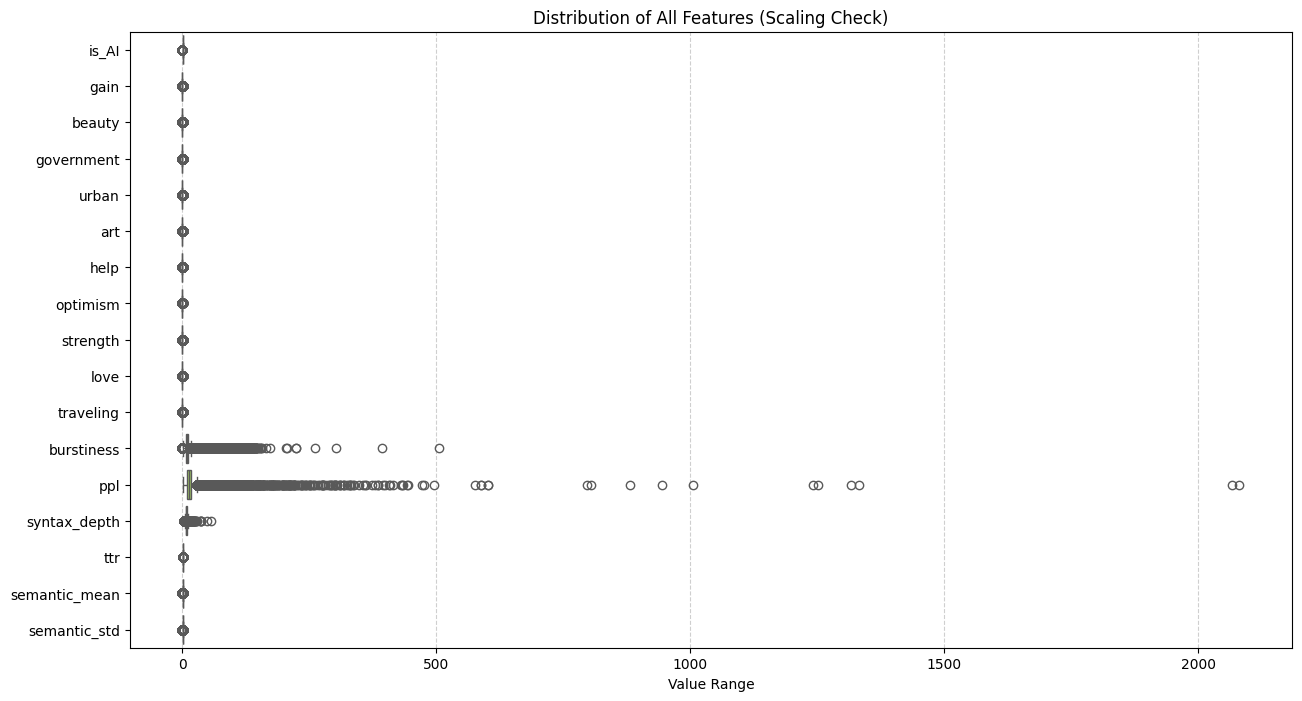

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt


features_to_plot = df.columns[1:]


plt.figure(figsize=(15, 8))
sns.boxplot(data=df, orient='h', palette='Set2')

plt.title('Distribution of All Features (Scaling Check)')
plt.xlabel('Value Range')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

since features like PPl, burstiness, TTR, and syntax tree have much larger ranges compared to others, we need to check the feature scaling.

and since Burstiness and ppl have a lot of outliers we will use RobustScaler

# Model Building

### Load and split the data

In [4]:
import pandas as pd
df=pd.read_csv("data/DB_final.csv")

In [8]:
df.sample(5)

,Text,model_builder,is_AI,gain,beauty,government,urban,art,help,optimism,strength,love,traveling,burstiness,ppl,syntax_depth,ttr,semantic_mean,semantic_std
35208,**The Photographer Behind the Scenes: Greg Kes...,llama-8B,1,0.000000,0.020528,0.000000,0.000000,0.008798,0.000000,0.000000,0.002933,0.002933,0.005865,7.422044,14.655614,7.230769,0.507082,0.418041,0.146445
13760,## A Nation Divided: How Different Groups Vot...,gemma-2-9b,1,0.005141,0.000000,0.017995,0.007712,0.005141,0.010283,0.005141,0.005141,0.000000,0.007712,6.659923,11.450743,7.136364,0.595908,0.406104,0.106375
2215,new video loaded:Hungarian Fence Doesn’t Deter...,Human_story,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.004024,0.000000,0.000000,0.002012,0.000000,86.263674,19.268604,7.923077,0.443378,0.284557,0.157290
7865,"## Clinton Commanding in Ohio, But ""Relatabili...",gemma-2-9b,1,0.000000,0.000000,0.014134,0.000000,0.000000,0.003534,0.003534,0.007067,0.007067,0.007067,8.562227,12.775741,5.947368,0.559028,0.352491,0.157494
25588,Title: Trump Mocks Kamala Harris at Pennsylvan...,qwen-2-72B,1,0.000000,0.000000,0.007732,0.000000,0.000000,0.002577,0.002577,0.000000,0.002577,0.000000,10.387975,8.687802,6.882353,0.532828,0.402483,0.185571


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

X = df.drop(columns=['Text', 'model_builder', 'is_AI'])
y = df['model_builder']
z = df['is_AI'] 


le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(
    X, 
    y_encoded, 
    z, 
    test_size=0.20, 
    random_state=999, 
    stratify=y_encoded   # ensure class distribution is maintained
)


robust_scaler = RobustScaler()

X_train = robust_scaler.fit_transform(X_train)

X_test = robust_scaler.transform(X_test)


print(f"X Train/Test: {X_train.shape} , {X_test.shape}")
print(f"y Train/Test: {len(y_train)} , {len(y_test)}")
print(f"z Train/Test: {len(z_train)} , {len(z_test)}")
print("Classes identified:", le.classes_)

X Train/Test: (40944, 16) , (10237, 16)
y Train/Test: 40944 , 10237
z Train/Test: 40944 , 10237
Classes identified: ['GPT_4-o' 'Human_story' 'accounts/yi-01-ai/models/yi-large' 'gemma-2-9b'
 'llama-8B' 'mistral-7B' 'qwen-2-72B']


## XGBoost Classifier

#### AI Generated vs Human-Written

In [6]:
import xgboost as xgb

clf_is_ai = xgb.XGBClassifier(
    objective='binary:logistic', 
    tree_method='hist',
    device='cuda',
    n_estimators=10000,
    learning_rate=0.05,
    max_depth=10,
    random_state=999
)

clf_is_ai.fit(X_train, z_train, eval_set=[(X_test, z_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

/home/basel/Work/python/ai_text_detection/.venv/lib/python3.11/site-packages/xgboost/core.py:774: UserWarning: [08:29:07] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

       Human       0.95      0.92      0.94      1459
          AI       0.99      0.99      0.99      8778

    accuracy                           0.98     10237
   macro avg       0.97      0.96      0.96     10237
weighted avg       0.98      0.98      0.98     10237



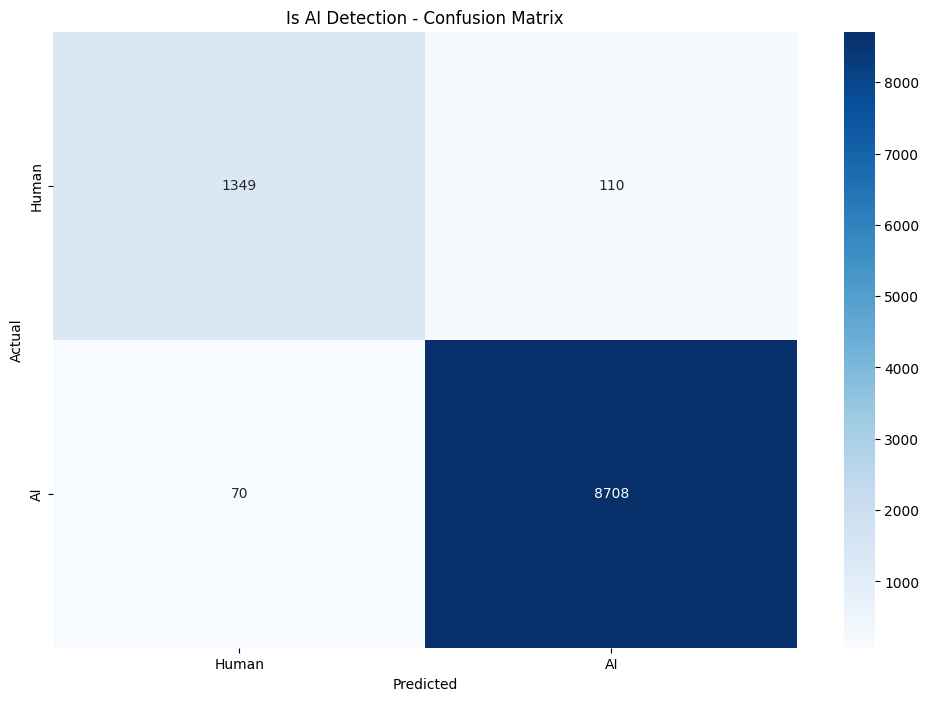

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

z_pred = clf_is_ai.predict(X_test)

print(classification_report(z_test, z_pred, target_names=['Human', 'AI']))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(z_test, z_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()

#

/tmp/ipykernel_344695/919564633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


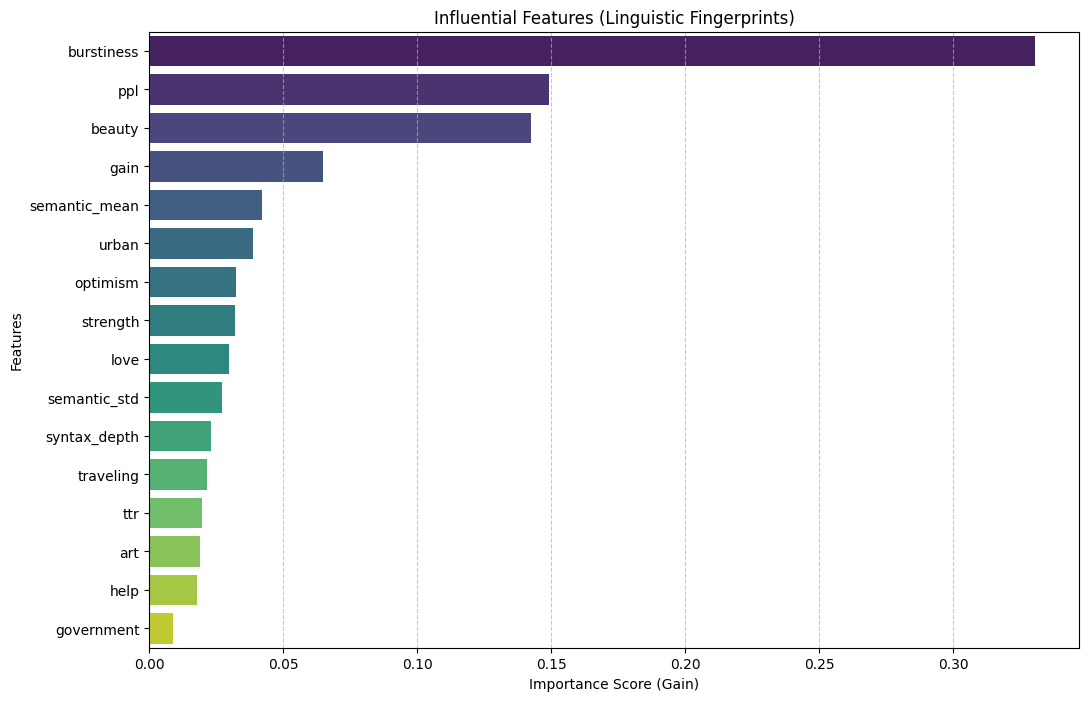

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = clf_is_ai.feature_importances_
feature_names = X.columns 


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Influential Features (Linguistic Fingerprints)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



#### model prediction

In [9]:
import xgboost as xgb


clf = xgb.XGBClassifier(
    n_estimators=10000,
    learning_rate=0.05,
    max_depth=10,
    objective='multi:softprob',  # multiclass classification
    tree_method='hist',          
    device='cuda',               # Use GPU acceleration
    random_state=999
)

print("Starting training on GPU...")
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("Training completed!")

Starting training on GPU...
Training completed!



Classification Report:
                                   precision    recall  f1-score   support

                          GPT_4-o       0.87      0.87      0.87      1465
                      Human_story       0.93      0.95      0.94      1459
accounts/yi-01-ai/models/yi-large       0.70      0.73      0.71      1464
                       gemma-2-9b       0.77      0.81      0.79      1462
                         llama-8B       0.61      0.61      0.61      1461
                       mistral-7B       0.50      0.46      0.48      1463
                       qwen-2-72B       0.64      0.61      0.62      1463

                         accuracy                           0.72     10237
                        macro avg       0.72      0.72      0.72     10237
                     weighted avg       0.72      0.72      0.72     10237



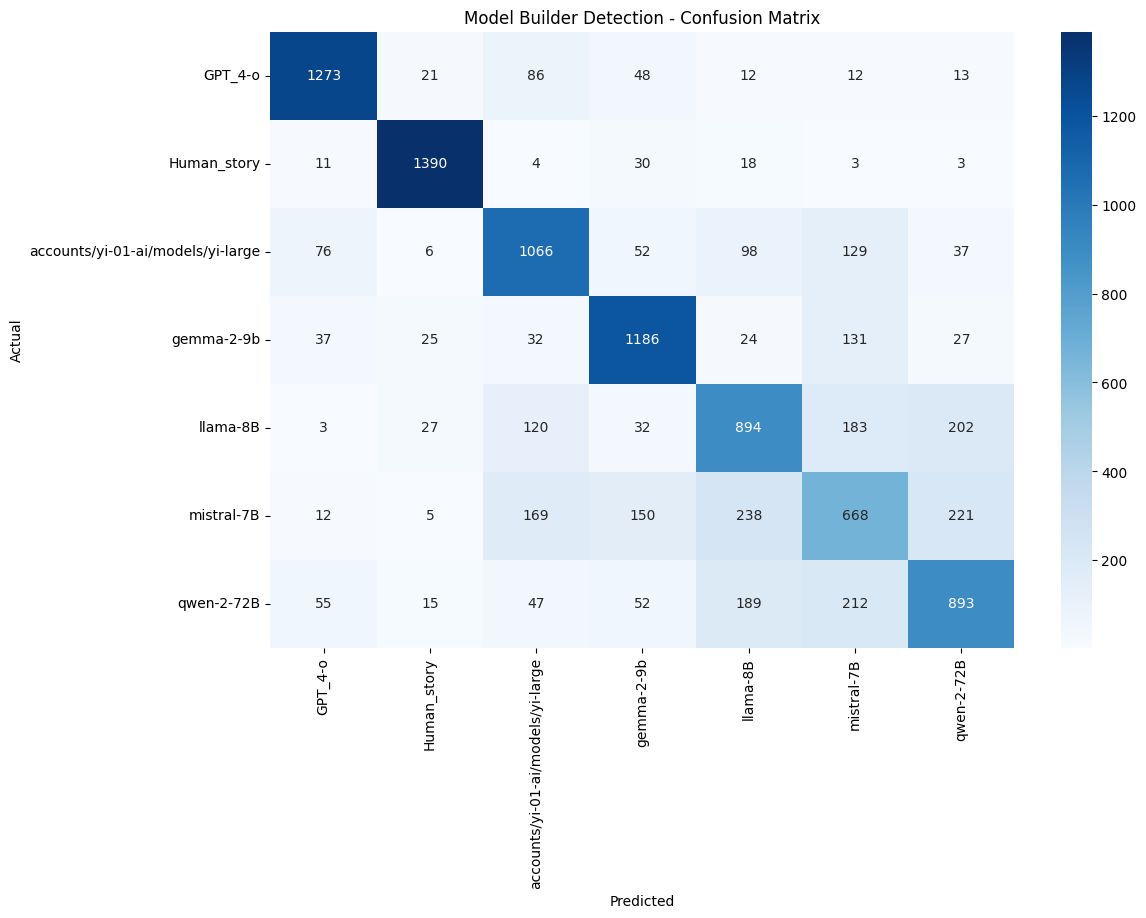

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = clf.predict(X_test)
# 
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Builder Detection - Confusion Matrix')
plt.show()

/tmp/ipykernel_344695/897342157.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


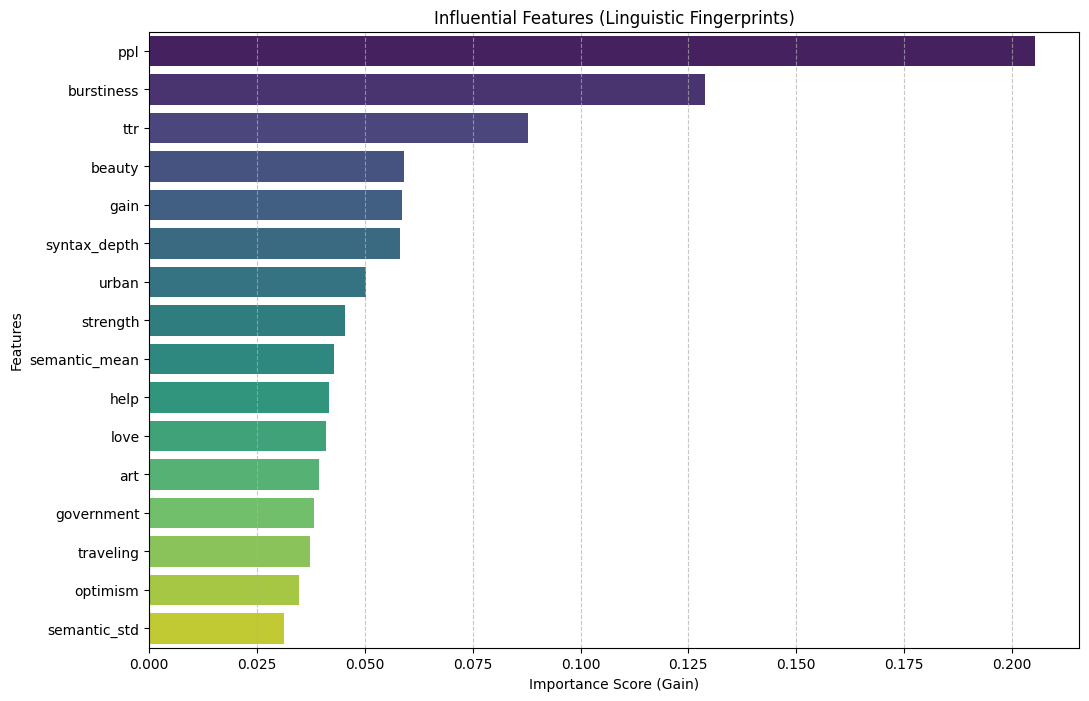

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = clf.feature_importances_
feature_names = X.columns 


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Influential Features (Linguistic Fingerprints)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



##  Random Forest

#### AI Generated vs Human-Written

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_is_ai = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=999,
    n_jobs=-1
)
rf_is_ai.fit(X_train, z_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

RF RESULTS FOR IS_AI (Binary)
              precision    recall  f1-score   support

       Human       0.96      0.90      0.93      1459
          AI       0.98      0.99      0.99      8778

    accuracy                           0.98     10237
   macro avg       0.97      0.95      0.96     10237
weighted avg       0.98      0.98      0.98     10237



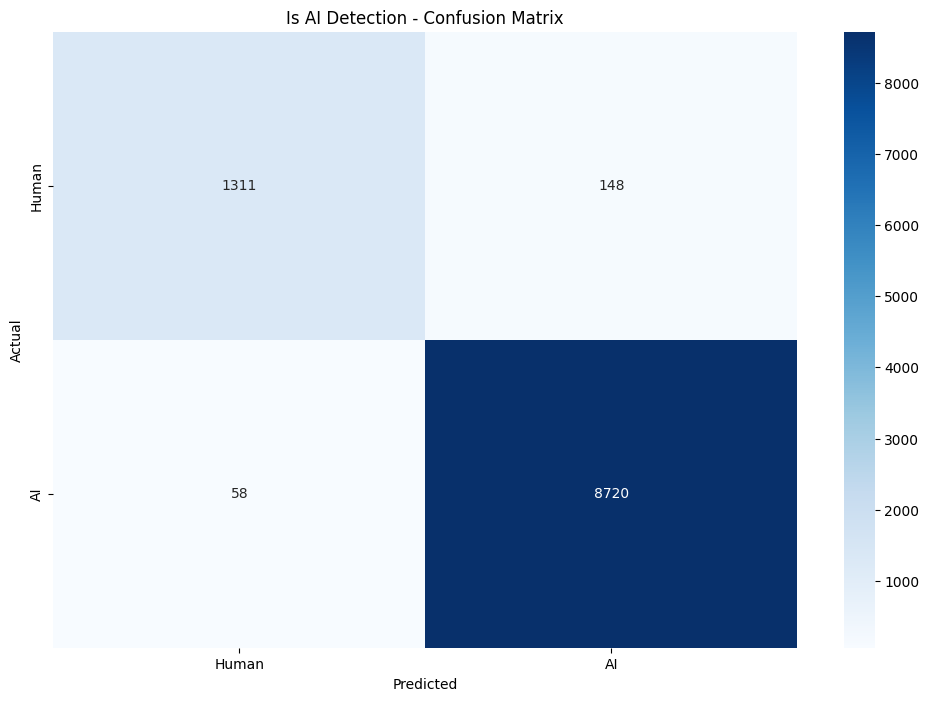

/tmp/ipykernel_344695/1764267769.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


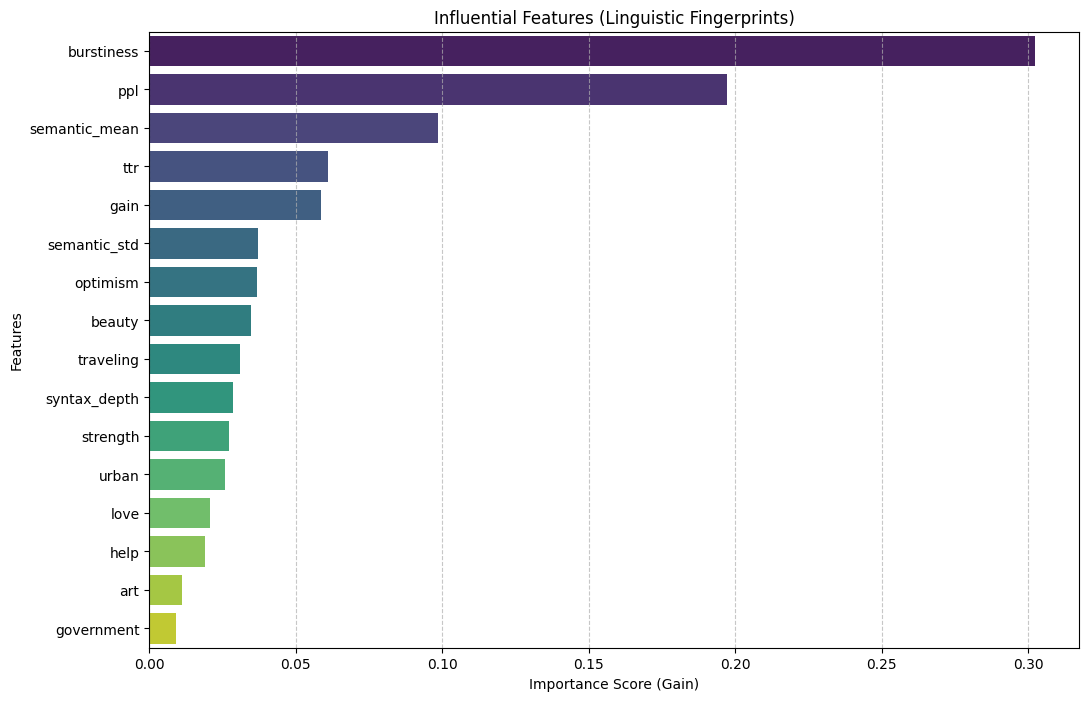

In [13]:
z_pred_rf = rf_is_ai.predict(X_test)

print("RF RESULTS FOR IS_AI (Binary)")
print(classification_report(z_test, z_pred_rf, target_names=['Human', 'AI']))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(z_test, z_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()


importances = rf_is_ai.feature_importances_
feature_names = X.columns 


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Influential Features (Linguistic Fingerprints)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


#### Model prediction

In [14]:
rf_model_type = RandomForestClassifier(
    n_estimators=500,  
    max_depth=15,      
    random_state=999,
    n_jobs=-1          # all CPU cores for speedup
)
rf_model_type.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

RF RESULTS FOR MODEL TYPE (Multi-class)
                                   precision    recall  f1-score   support

                          GPT_4-o       0.77      0.84      0.80      1465
                      Human_story       0.92      0.93      0.93      1459
accounts/yi-01-ai/models/yi-large       0.65      0.70      0.67      1464
                       gemma-2-9b       0.71      0.76      0.74      1462
                         llama-8B       0.59      0.58      0.58      1461
                       mistral-7B       0.52      0.41      0.46      1463
                       qwen-2-72B       0.62      0.60      0.61      1463

                         accuracy                           0.69     10237
                        macro avg       0.68      0.69      0.68     10237
                     weighted avg       0.68      0.69      0.68     10237



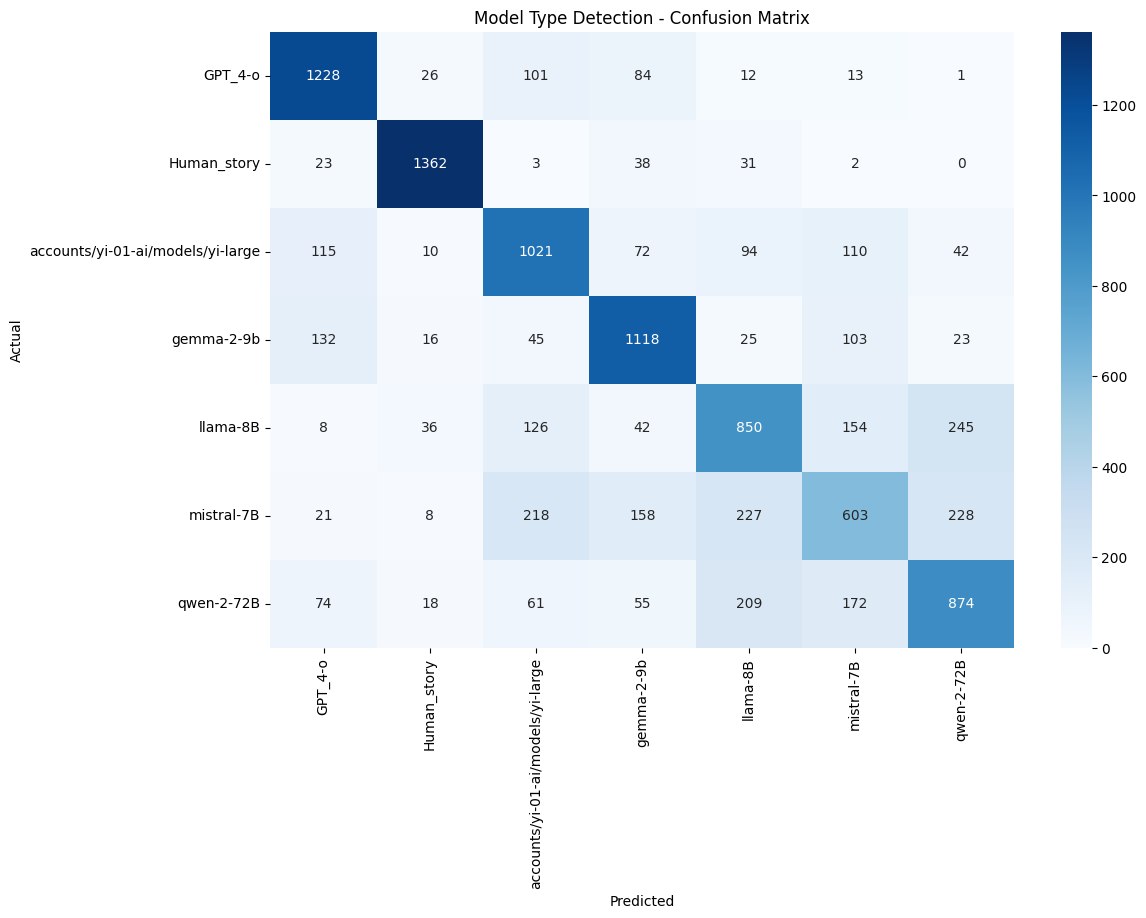

/tmp/ipykernel_344695/2443122132.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


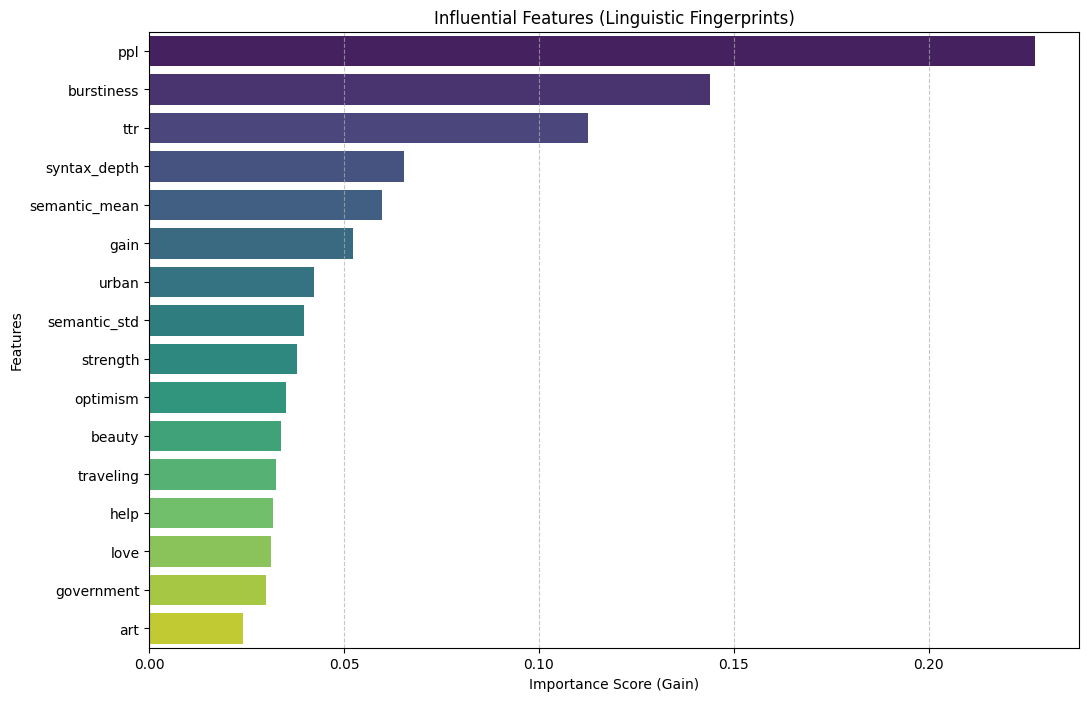

In [15]:
# تنبؤات RF
y_pred_rf = rf_model_type.predict(X_test)

print("RF RESULTS FOR MODEL TYPE (Multi-class)")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Type Detection - Confusion Matrix')
plt.show()


importances = rf_model_type.feature_importances_
feature_names = X.columns 


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Influential Features (Linguistic Fingerprints)')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## SVM

#### AI Generated vs Human-Written

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

svm_is_ai = SVC(
    kernel='rbf',    # most common choice
    C=1.0,           # regularization parameter
    probability=True, # to extract probabilities later
    cache_size=1000, 
    random_state=999
)

svm_is_ai.fit(X_train, z_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",1000
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


              precision    recall  f1-score   support

       Human       0.93      0.90      0.92      1459
          AI       0.98      0.99      0.99      8778

    accuracy                           0.98     10237
   macro avg       0.96      0.95      0.95     10237
weighted avg       0.98      0.98      0.98     10237



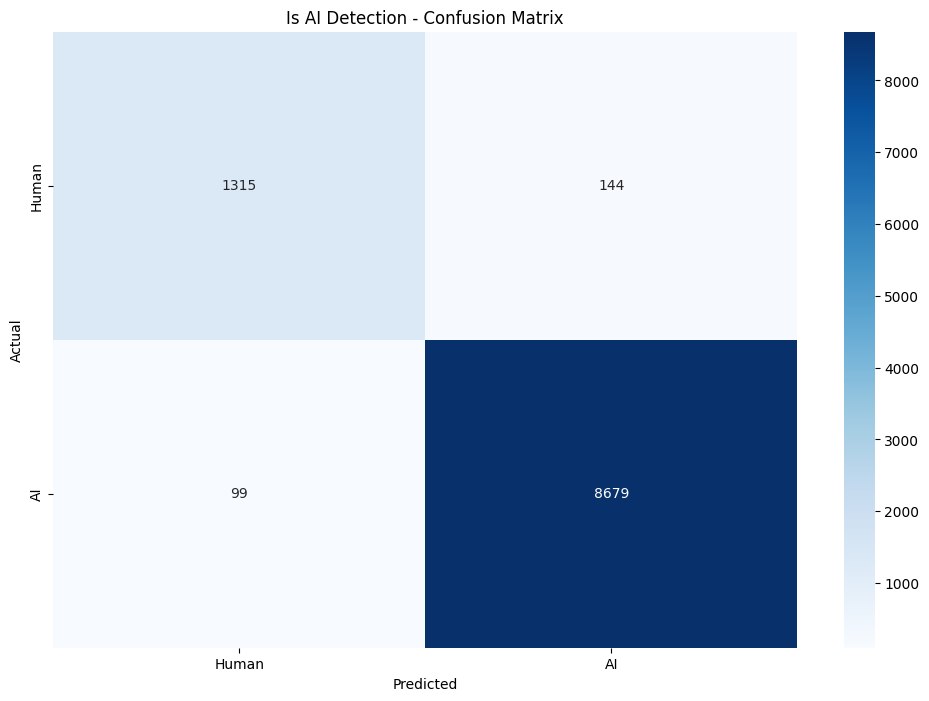

Total Support Vectors: 2902
Support Vectors per class (Human, AI): [1470 1432]
Dual Coefficients Shape: (1, 2902)


<Figure size 1000x700 with 0 Axes>

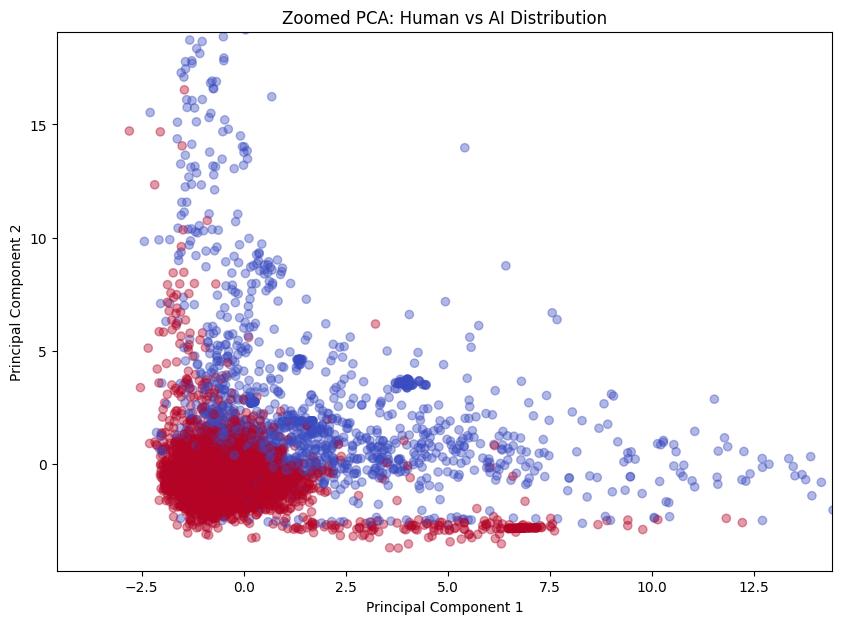

In [17]:
z_pred_svm = svm_is_ai.predict(X_test)

print(classification_report(z_test, z_pred_svm, target_names=['Human', 'AI']))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(z_test, z_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()


sv_indices = svm_is_ai.support_
n_sv = svm_is_ai.n_support_

d_coefs = svm_is_ai.dual_coef_

print(f"Total Support Vectors: {len(sv_indices)}")
print(f"Support Vectors per class (Human, AI): {n_sv}")
print(f"Dual Coefficients Shape: {d_coefs.shape}")

from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(10, 7))

# scatter plot but remove outliers for better visualization
x_limit = np.percentile(X_test_pca[:, 0], 99)
y_limit = np.percentile(X_test_pca[:, 1], 99)

plt.figure(figsize=(10, 7))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=z_test, cmap='coolwarm', alpha=0.4)

plt.xlim(np.min(X_test_pca[:, 0]) - 1, x_limit + 5)
plt.ylim(np.min(X_test_pca[:, 1]) - 1, y_limit + 5)

plt.title('Zoomed PCA: Human vs AI Distribution')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

#### Model prediction

In [18]:
svm_model_type = SVC(
    kernel='rbf',
    decision_function_shape='ovr', # one-vs-rest for multi-class
    cache_size=1000,
    random_state=999,
    C=1.0,           # regularization parameter
    probability=True # to extract probabilities later

)

svm_model_type.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",1000
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


                                   precision    recall  f1-score   support

                          GPT_4-o       0.74      0.77      0.76      1465
                      Human_story       0.90      0.93      0.92      1459
accounts/yi-01-ai/models/yi-large       0.62      0.61      0.61      1464
                       gemma-2-9b       0.68      0.73      0.70      1462
                         llama-8B       0.54      0.53      0.54      1461
                       mistral-7B       0.46      0.41      0.43      1463
                       qwen-2-72B       0.57      0.55      0.56      1463

                         accuracy                           0.65     10237
                        macro avg       0.64      0.65      0.65     10237
                     weighted avg       0.64      0.65      0.65     10237



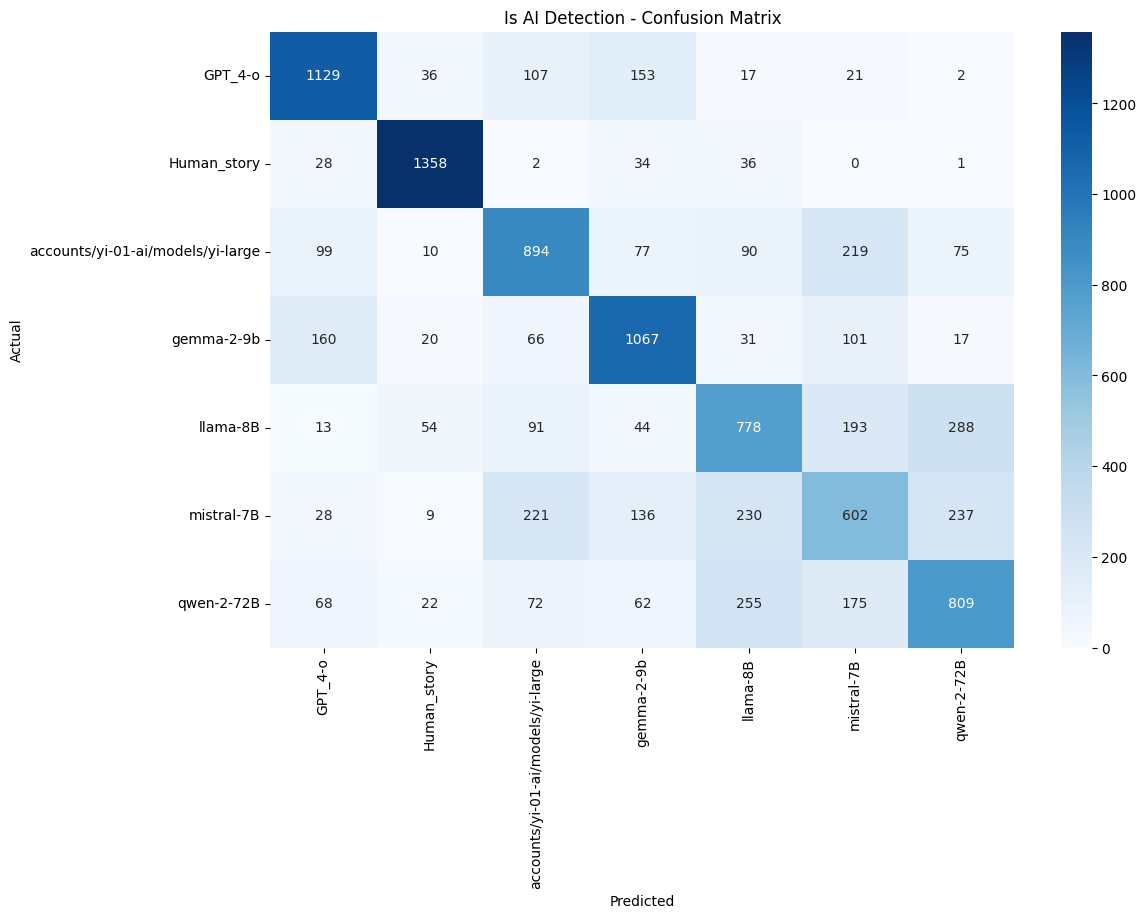

Total Support Vectors: 2902
Support Vectors per class (Human, AI): [1470 1432]
Dual Coefficients Shape: (1, 2902)


<Figure size 1000x700 with 0 Axes>

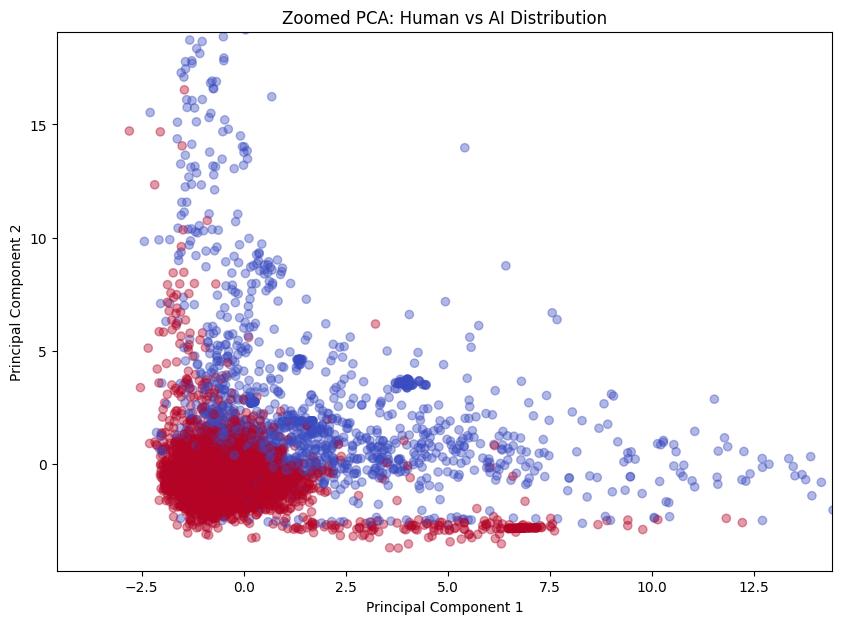

In [19]:
y_pred_svm = svm_model_type.predict(X_test)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))


plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()


sv_indices = svm_is_ai.support_
n_sv = svm_is_ai.n_support_

d_coefs = svm_is_ai.dual_coef_

print(f"Total Support Vectors: {len(sv_indices)}")
print(f"Support Vectors per class (Human, AI): {n_sv}")
print(f"Dual Coefficients Shape: {d_coefs.shape}")

from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(10, 7))

# scatter plot but remove outliers for better visualization
x_limit = np.percentile(X_test_pca[:, 0], 99)
y_limit = np.percentile(X_test_pca[:, 1], 99)

plt.figure(figsize=(10, 7))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=z_test, cmap='coolwarm', alpha=0.4)

plt.xlim(np.min(X_test_pca[:, 0]) - 1, x_limit + 5)
plt.ylim(np.min(X_test_pca[:, 1]) - 1, y_limit + 5)

plt.title('Zoomed PCA: Human vs AI Distribution')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Naive Bayes

In [20]:
from sklearn.naive_bayes import GaussianNB

print("--- Training Naive Bayes: Is AI or Not (z) ---")
nb_is_ai = GaussianNB()
nb_is_ai.fit(X_train, z_train)

print("\n--- Training Naive Bayes: Model Type (y) ---")
nb_model_type = GaussianNB()
nb_model_type.fit(X_train, y_train)

print("\nNaive Bayes models trained successfully!")

--- Training Naive Bayes: Is AI or Not (z) ---

--- Training Naive Bayes: Model Type (y) ---

Naive Bayes models trained successfully!


NAIVE BAYES RESULTS: IS_AI (Binary)
              precision    recall  f1-score   support

       Human       0.80      0.81      0.80      1459
          AI       0.97      0.97      0.97      8778

    accuracy                           0.94     10237
   macro avg       0.89      0.89      0.89     10237
weighted avg       0.94      0.94      0.94     10237



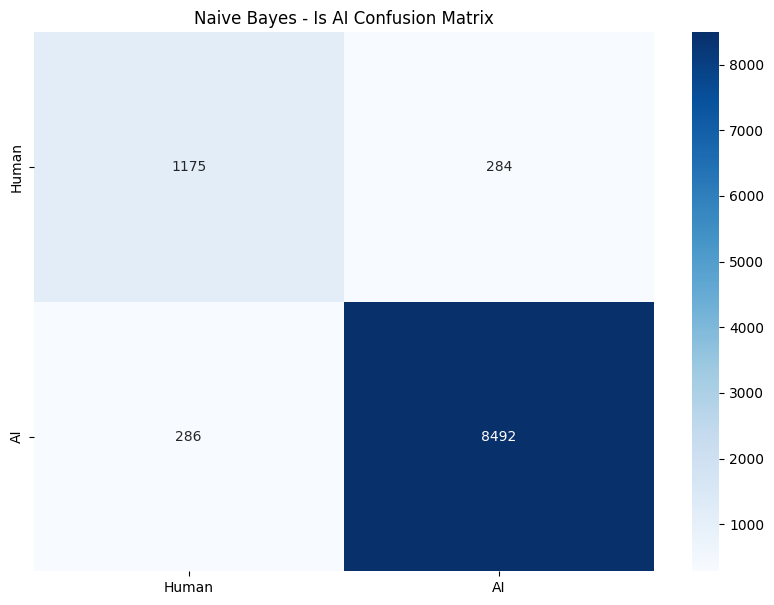

In [21]:
z_pred_nb = nb_is_ai.predict(X_test)

print("NAIVE BAYES RESULTS: IS_AI (Binary)")
print(classification_report(z_test, z_pred_nb, target_names=['Human', 'AI']))

plt.figure(figsize=(10, 7))
cm_nb = confusion_matrix(z_test, z_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Naive Bayes - Is AI Confusion Matrix')
plt.show()

NAIVE BAYES RESULTS: MODEL TYPE (Multi-class)
                                   precision    recall  f1-score   support

                          GPT_4-o       0.45      0.29      0.35      1465
                      Human_story       0.81      0.81      0.81      1459
accounts/yi-01-ai/models/yi-large       0.42      0.58      0.49      1464
                       gemma-2-9b       0.46      0.66      0.54      1462
                         llama-8B       0.50      0.11      0.18      1461
                       mistral-7B       0.33      0.39      0.36      1463
                       qwen-2-72B       0.44      0.49      0.46      1463

                         accuracy                           0.48     10237
                        macro avg       0.49      0.48      0.46     10237
                     weighted avg       0.49      0.48      0.46     10237



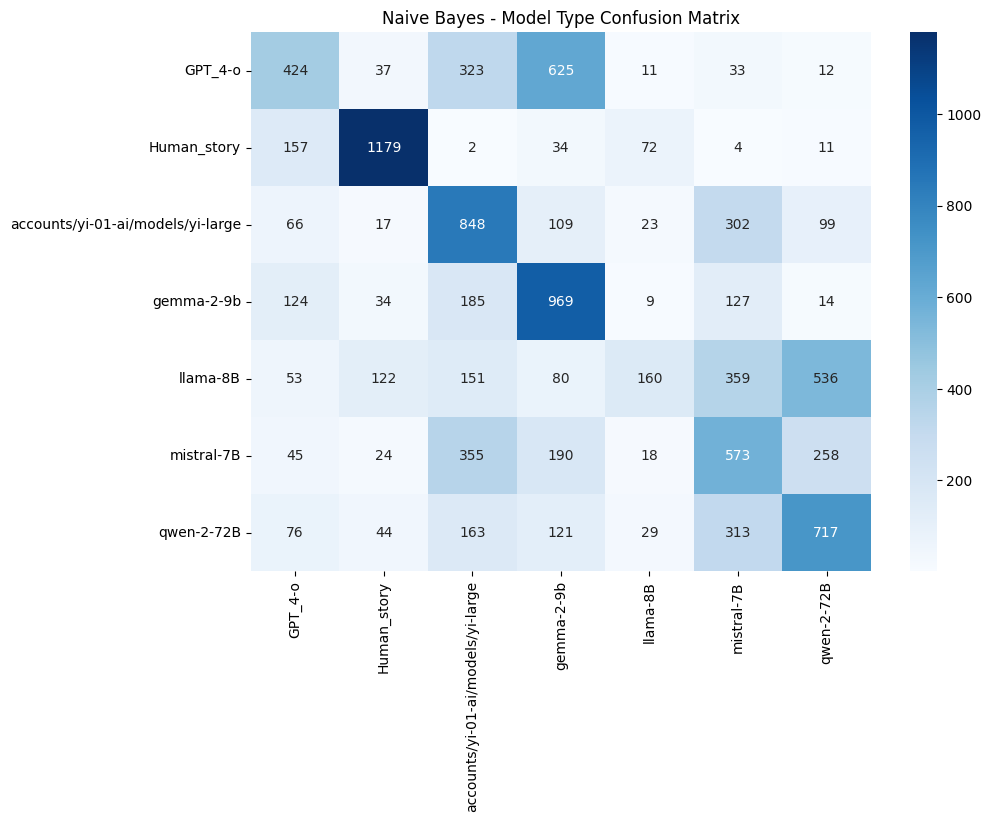

In [22]:
y_pred_nb = nb_model_type.predict(X_test)

print("NAIVE BAYES RESULTS: MODEL TYPE (Multi-class)")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

plt.figure(figsize=(10, 7))
cm_nb_type = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb_type, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Naive Bayes - Model Type Confusion Matrix')
plt.show()
            

## linear classifier

In [23]:
from sklearn.linear_model import LogisticRegression

print("--- Training Logistic Regression: Is AI or Not (z) ---")
lr_is_ai = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr_is_ai.fit(X_train, z_train)

print("\n--- Training Logistic Regression: Model Type (y) ---")
lr_model_type = LogisticRegression(
    max_iter=1000,
    solver='lbfgs', # multi class classifier
    random_state=42
)
lr_model_type.fit(X_train, y_train)

print("\nLinear models trained successfully!")

--- Training Logistic Regression: Is AI or Not (z) ---

--- Training Logistic Regression: Model Type (y) ---

Linear models trained successfully!


              precision    recall  f1-score   support

       Human       0.90      0.81      0.85      1459
          AI       0.97      0.99      0.98      8778

    accuracy                           0.96     10237
   macro avg       0.94      0.90      0.92     10237
weighted avg       0.96      0.96      0.96     10237



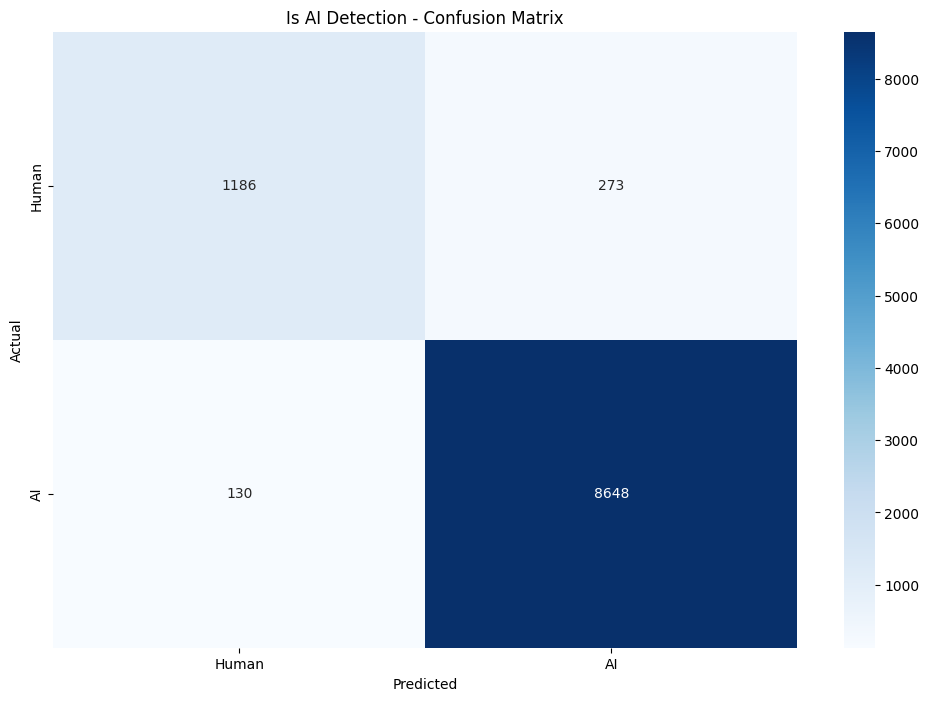

In [24]:
z_pred_lr = lr_is_ai.predict(X_test)

print(classification_report(z_test, z_pred_lr, target_names=['Human', 'AI']))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(z_test, z_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()

                                   precision    recall  f1-score   support

                          GPT_4-o       0.64      0.66      0.65      1465
                      Human_story       0.81      0.85      0.83      1459
accounts/yi-01-ai/models/yi-large       0.54      0.48      0.51      1464
                       gemma-2-9b       0.60      0.64      0.62      1462
                         llama-8B       0.34      0.32      0.33      1461
                       mistral-7B       0.40      0.30      0.34      1463
                       qwen-2-72B       0.48      0.61      0.54      1463

                         accuracy                           0.55     10237
                        macro avg       0.54      0.55      0.55     10237
                     weighted avg       0.54      0.55      0.55     10237



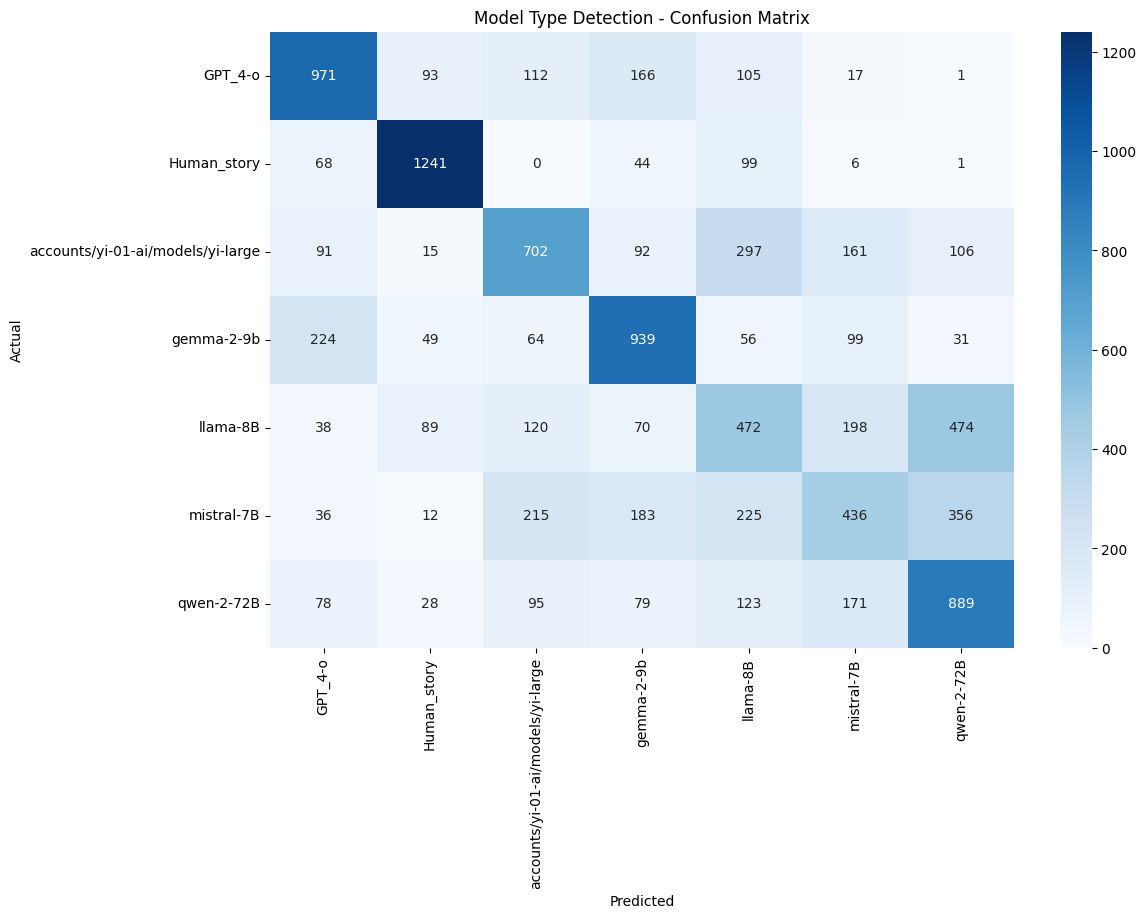

In [25]:
y_pred_lr = lr_model_type.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=le.classes_))
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Type Detection - Confusion Matrix')
plt.show()

## KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

print("--- Training KNN: Is AI or Not (z) ---")
knn_is_ai = KNeighborsClassifier(
    n_neighbors=5, 
    weights='distance', 
    metric='euclidean', 
    n_jobs=-1           
)
knn_is_ai.fit(X_train, z_train)

print("\n--- Training KNN: Model Type (y) ---")
knn_model_type = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    n_jobs=-1
)
knn_model_type.fit(X_train, y_train)

print("\nKNN models trained successfully!")

--- Training KNN: Is AI or Not (z) ---

--- Training KNN: Model Type (y) ---

KNN models trained successfully!


              precision    recall  f1-score   support

       Human       0.93      0.91      0.92      1459
          AI       0.98      0.99      0.99      8778

    accuracy                           0.98     10237
   macro avg       0.96      0.95      0.95     10237
weighted avg       0.98      0.98      0.98     10237



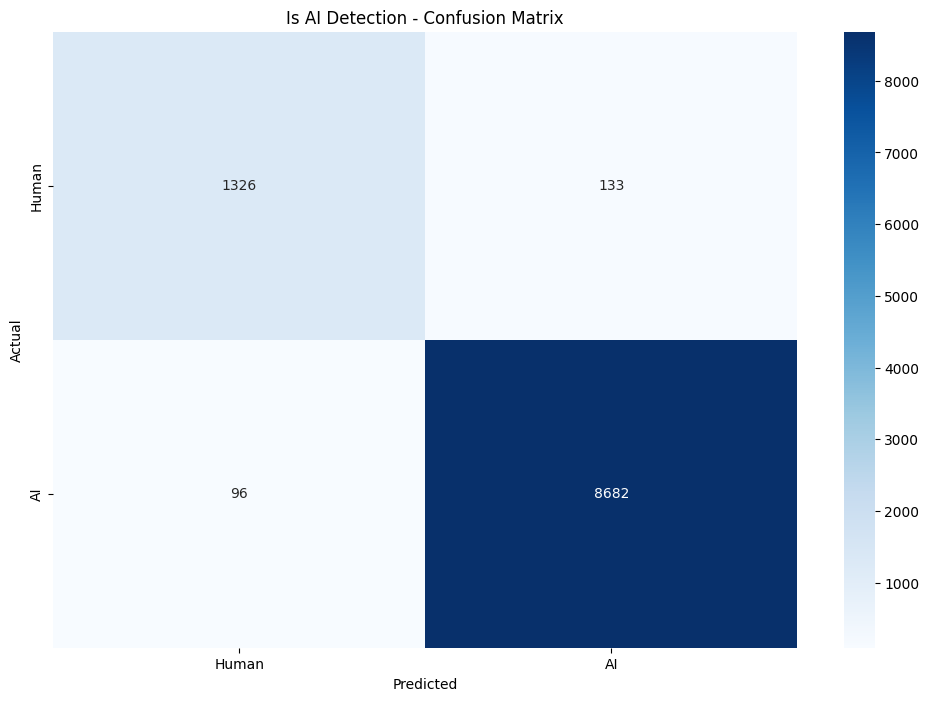

In [27]:
z_pred_knn = knn_is_ai.predict(X_test)

print(classification_report(z_test, z_pred_knn, target_names=['Human', 'AI']))


plt.figure(figsize=(12, 8))
cm = confusion_matrix(z_test, z_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()

                                   precision    recall  f1-score   support

                          GPT_4-o       0.60      0.76      0.67      1465
                      Human_story       0.91      0.93      0.92      1459
accounts/yi-01-ai/models/yi-large       0.44      0.52      0.47      1464
                       gemma-2-9b       0.64      0.55      0.59      1462
                         llama-8B       0.45      0.42      0.43      1461
                       mistral-7B       0.33      0.30      0.31      1463
                       qwen-2-72B       0.43      0.34      0.38      1463

                         accuracy                           0.55     10237
                        macro avg       0.54      0.55      0.54     10237
                     weighted avg       0.54      0.55      0.54     10237



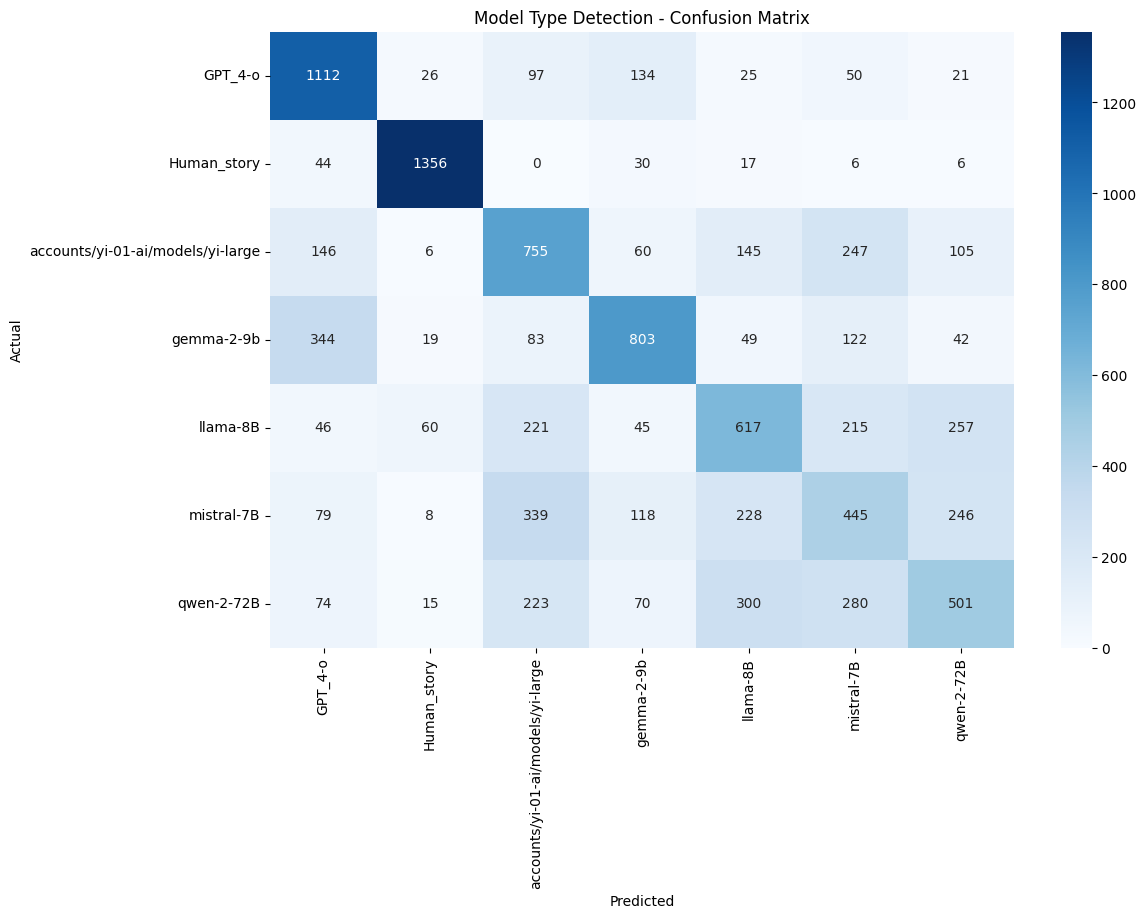

In [28]:
y_pred_knn = knn_model_type.predict(X_test)
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Type Detection - Confusion Matrix')
plt.show()

## Ada Boost

a lot of one leaf DT where each one learn from previous DT mistake ,and voting has wight

In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


print("--- Training AdaBoost: Is AI or Not (z) ---")

ada_is_ai = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100, 
    learning_rate=1.0,
    random_state=42
)
ada_is_ai.fit(X_train, z_train)


print("\n--- Training AdaBoost: Model Type (y) ---")
ada_model_type = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada_model_type.fit(X_train, y_train)

print("\nAdaBoost models trained successfully!")

--- Training AdaBoost: Is AI or Not (z) ---

--- Training AdaBoost: Model Type (y) ---

AdaBoost models trained successfully!


              precision    recall  f1-score   support

       Human       0.91      0.86      0.88      1459
          AI       0.98      0.99      0.98      8778

    accuracy                           0.97     10237
   macro avg       0.94      0.92      0.93     10237
weighted avg       0.97      0.97      0.97     10237



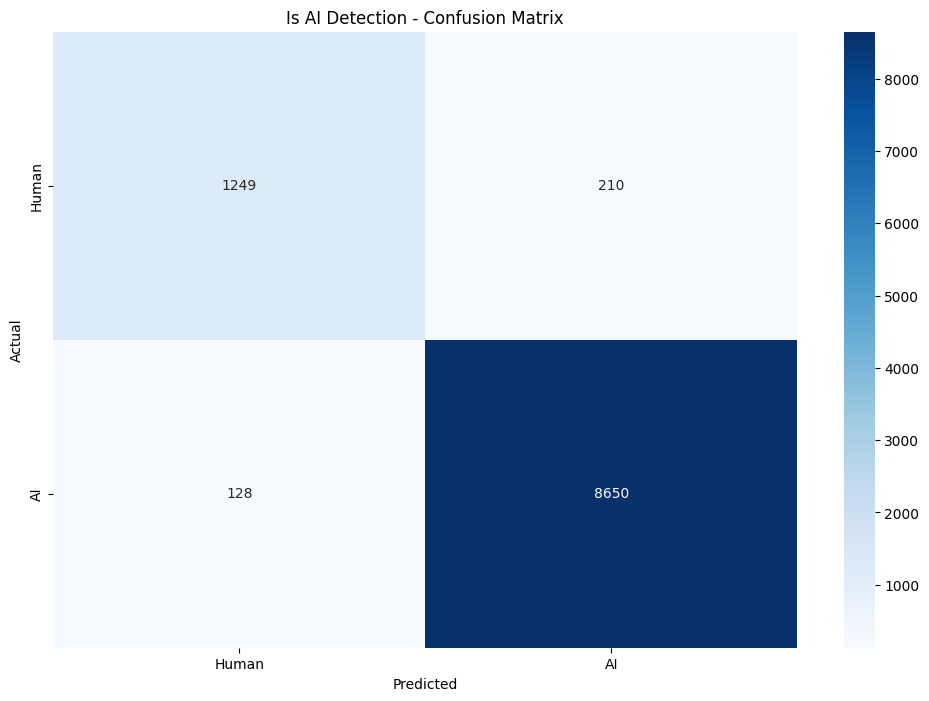

In [30]:
z_pred_ada = ada_is_ai.predict(X_test)

print(classification_report(z_test, z_pred_ada, target_names=['Human', 'AI']))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(z_test, z_pred_ada)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'], cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Is AI Detection - Confusion Matrix')
plt.show()

                                   precision    recall  f1-score   support

                          GPT_4-o       0.62      0.67      0.65      1465
                      Human_story       0.88      0.77      0.82      1459
accounts/yi-01-ai/models/yi-large       0.49      0.49      0.49      1464
                       gemma-2-9b       0.58      0.63      0.60      1462
                         llama-8B       0.44      0.43      0.43      1461
                       mistral-7B       0.34      0.28      0.31      1463
                       qwen-2-72B       0.36      0.42      0.39      1463

                         accuracy                           0.53     10237
                        macro avg       0.53      0.53      0.53     10237
                     weighted avg       0.53      0.53      0.53     10237



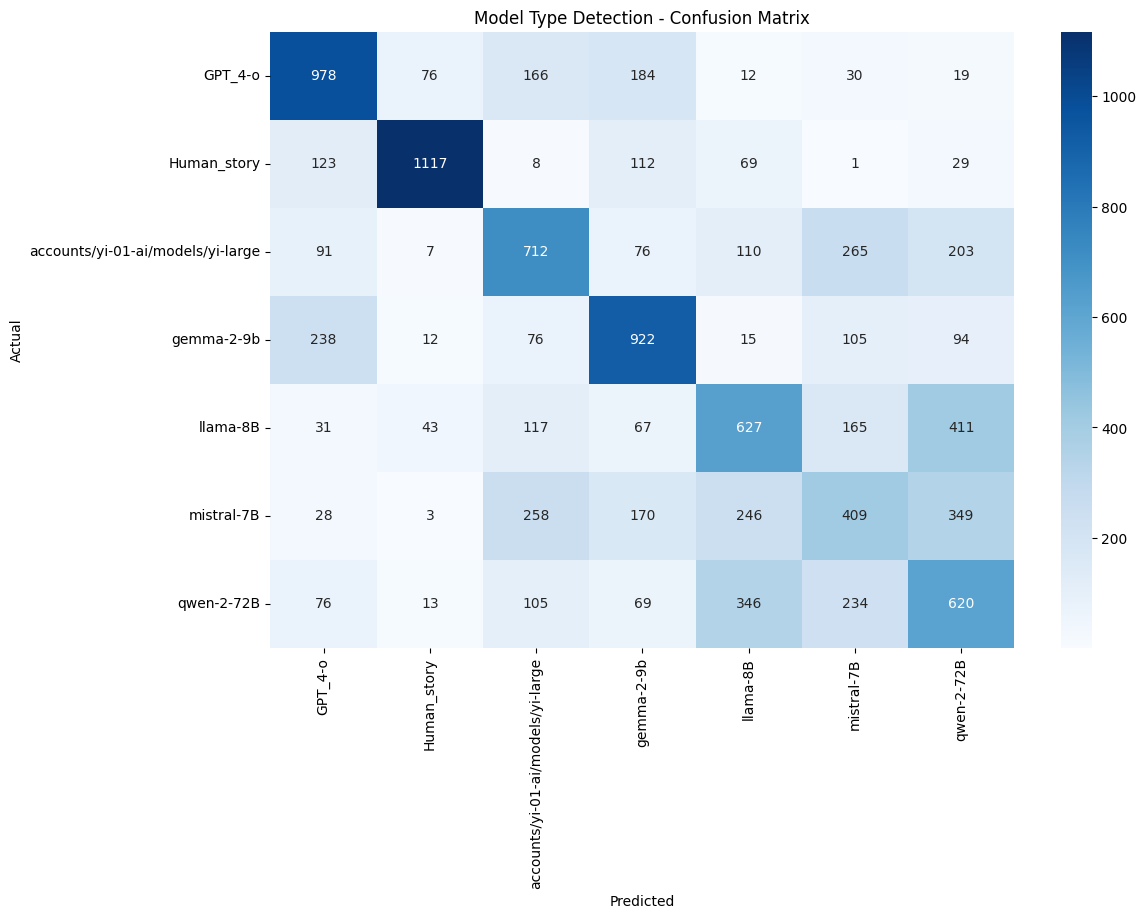

In [31]:
y_pred_ada = ada_model_type.predict(X_test)

print(classification_report(y_test, y_pred_ada, target_names=le.classes_))

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Type Detection - Confusion Matrix')
plt.show()

## Neural Network - NN

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# convert all features into tensor 
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# Batch the data
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)

# Loos function $$FL(p_t) = -(1 - p_t)^\gamma \log(p_t)$$ 
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

class AIClassifierNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AIClassifierNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1),
            
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))
model = AIClassifierNet(input_dim, num_classes).to(device)

criterion = FocalLoss(gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

epochs = 400
print("Starting Training...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward() 
        optimizer.step() # weight update
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    
    if (epoch + 1) % 40 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    _, predictions = torch.max(test_outputs, 1)
    y_pred_nn = predictions.cpu().numpy()

print("\n--- Final Neural Network Classification Report ---")
print(classification_report(y_test, y_pred_nn, target_names=le.classes_))

Using device: cuda
Starting Training...
Epoch [40/400], Loss: 0.4749
Epoch [80/400], Loss: 0.4407
Epoch [120/400], Loss: 0.4443
Epoch [160/400], Loss: 0.4425
Epoch [200/400], Loss: 0.4417
Epoch [240/400], Loss: 0.4460
Epoch [280/400], Loss: 0.4424
Epoch [320/400], Loss: 0.4422
Epoch [360/400], Loss: 0.4456
Epoch [400/400], Loss: 0.4424

--- Final Neural Network Classification Report ---
                                   precision    recall  f1-score   support

                          GPT_4-o       0.67      0.85      0.75      1465
                      Human_story       0.92      0.93      0.93      1459
accounts/yi-01-ai/models/yi-large       0.46      0.75      0.57      1464
                       gemma-2-9b       0.67      0.72      0.70      1462
                         llama-8B       0.61      0.36      0.46      1461
                       mistral-7B       0.38      0.39      0.39      1463
                       qwen-2-72B       0.72      0.30      0.43      1463

        

# Summary

In [34]:
import pandas as pd
from sklearn.metrics import classification_report

def extract_metrics_to_df(report_dict, model_name, task_name):
    accuracy = report_dict['accuracy']
    macro_avg = report_dict['macro avg']
    
    row = {
        'Task': task_name,
        'Model': model_name,
        'Accuracy': round(accuracy, 2),
        'Precision (Macro)': round(macro_avg['precision'], 2),
        'Recall (Macro)': round(macro_avg['recall'], 2),
        'F1-Score (Macro)': round(macro_avg['f1-score'], 2)
    }
    return pd.DataFrame([row])

all_summaries = []

# XGBoost
report_xgb_ai = classification_report(z_test, z_pred,output_dict=True)
all_summaries.append(extract_metrics_to_df(report_xgb_ai, "XGBoost", "AI-vs-Human"))
report_xgb_dict = classification_report(y_test, y_pred,output_dict=True)
all_summaries.append(extract_metrics_to_df(report_xgb_dict, "XGBoost", "Multi-class"))


# 2. Random Forest
report_rf_ai = classification_report(z_test, z_pred_rf, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_rf_ai, "Random Forest", "AI-vs-Human"))
report_rf_dict = classification_report(y_test, y_pred_rf, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_rf_dict, "Random Forest", "Multi-class"))

# 3. SVM 
report_svm_ai = classification_report(z_test, z_pred_svm, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_svm_ai, "SVM", "AI-vs-Human"))

report_svm_dict = classification_report(y_test, y_pred_svm, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_svm_dict, "SVM", "Multi-class"))

# 4. Naive Bayes 

report_nb_ai = classification_report(z_test, z_pred_nb, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_nb_ai, "Naive Bayes", "AI-vs-Human"))

report_nb_dict = classification_report(y_test, y_pred_nb, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_nb_dict, "Naive Bayes", "Multi-class"))

# 5. Linear Classifier 

report_lr_ai = classification_report(z_test, z_pred_lr, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_lr_ai, "Logistic Regression", "AI-vs-Human"))

report_lr_dict = classification_report(y_test, y_pred_lr, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_lr_dict, "Logistic Regression", "Multi-class"))

# 6. KNN 
report_knn_ai = classification_report(z_test, z_pred_knn, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_knn_ai, "KNN", "AI-vs-Human"))

report_knn_dict = classification_report(y_test, y_pred_knn, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_knn_dict, "KNN", "Multi-class"))

# 7. AdaBoost (Multi-class)

report_ada_ai = classification_report(z_test, z_pred_ada, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_ada_ai, "AdaBoost", "AI-vs-Human"))

report_ada_dict = classification_report(y_test, y_pred_ada, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_ada_dict, "AdaBoost", "Multi-class"))

# # 8. Neural Network (Multi-class)
report_nn_dict = classification_report(y_test, y_pred_nn, output_dict=True)
all_summaries.append(extract_metrics_to_df(report_nn_dict, "Neural Network", "Multi-class"))

# merge
final_table = pd.concat(all_summaries)


print(final_table.sort_values(by='Accuracy', ascending=False).to_string(index=False))

       Task               Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
AI-vs-Human             XGBoost      0.98               0.97            0.96              0.96
AI-vs-Human       Random Forest      0.98               0.97            0.95              0.96
AI-vs-Human                 SVM      0.98               0.96            0.95              0.95
AI-vs-Human                 KNN      0.98               0.96            0.95              0.95
AI-vs-Human            AdaBoost      0.97               0.94            0.92              0.93
AI-vs-Human Logistic Regression      0.96               0.94            0.90              0.92
AI-vs-Human         Naive Bayes      0.94               0.89            0.89              0.89
Multi-class             XGBoost      0.72               0.72            0.72              0.72
Multi-class       Random Forest      0.69               0.68            0.69              0.68
Multi-class                 SVM      0.65         